## Setup for LSTM

In [469]:
#pip install --upgrade pip
#%pip install keras
#%pip install tensorflow 

In [470]:
#%pip install keras

In [471]:
 #%pip install tensorflow 

In [472]:
# Importing required libraries
import requests
import pandas as pd
import csv
import numpy as np
from itertools import permutations

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from statsmodels.tsa.seasonal import seasonal_decompose
# this for time series
#import statsmodels.formula.api as smf
#from statsmodels.tsa.seasonal import seasonal_decompose
#from scipy.ndimage import gaussian_filter
#from calendar import monthrange
#from calendar import month_name
#from sklearn.metrics import mean_squared_error
#from math import sqrt
#from statsmodels.tsa.stattools import adfuller,kpss
#from statsmodels.tsa.seasonal import seasonal_decompose
#from statsmodels.tsa.arima_model import ARIMA
#from statsmodels.graphics.tsaplots import plot_pacf
#from pmdarima.arima import auto_arima
#import statsmodels.graphics.tsaplots as tsaplot
#from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing, SimpleExpSmoothing

#import tensorflow as tf
#from keras.models import Sequential
#from keras.layers import LSTM, Dense

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.models import load_model
import time



### Columns
|Name                | Description                                                                   | Type     |Energy Source
|---------------------|-------------------------------------------------------------------------------|----------|----------|
| Area       |     Whole Germany                          |object   |     |
| Mtu     |                                  | object  |    |
| Biomass_mwh         |     Biomass                 | float64 |Renewable |
| Fossil_brown_coal_mwh      | Fossil brown coal              | float64 |Fossil  Fuels|
| Fossil_coal_derived_gas_mwh    |    Fossil coal derived gas       | float64 |Fossil  Fuels |
| Fossil_gas_mwh      |      Fossil gas                | float64 |Fossil  Fuels|
| Fossil_hard_coal_mwh     |      Fossil hard coal           | float64 |Fossil  Fuels|
| Fossil_oil_mwh      |       Fossil oil               | float64 |Fossil  Fuels|
| Fossil_oil_shale_mwh     |    Fossil oil shale             | float64 |Fossil  Fuels   |
| Fossil_peat_mwh     |   Fossil peat                    | float64 |Fossil  Fuels |
| Geothermal_mwh    |        Geothermal                | float64 |Renewable|
| Hydro_pumped_storage_aggregated_mwh  | Hydro pumped storage (generation)    | float64 |    |
| Hydro_pumped_storage_consumption_mwh   | Hydro pumped storage (consumption)| float64 |    |
| Hydro_run_of_river_and_poundage_mwh   | Hydro run of river and poundage   | float64 |Renewable|
| Hydro_water_reservoir_mwh  |    Hydro water reservoir             | float64 |Renewable|
| Marine_mwh     |   Marine                        | float64 |Renewable|
| Nuclear_mwh  |       Nuclear                       | float64 |Nuclear   |
| Other_mwh     |       Other                     | float64 |    |
| Other_renewable_mwh     |    Other renewable              | float64 |Renewable|
| Solar_mwh     |      Solar                      | float64 |Renewable |
| Waste_mwh    |     Waste                        | float64 |Renewable  |
| Wind_offshore_mwh    |  Wind offshore                   | float6  |Renewable |
| Wind_onshore_mwh   |      Wind onshore                 | float64 |Renewable  |
| Date                  |   Date(yyyy-mm-dd)                 | int64 |    |
| Hour        |Timesatmp of 'UTC+1' timezone                          | int64 |    |
| Total_energy_generation_mwh   | Total energy generation of Germany           | float64 |    |
| Total_other_renewable_mwh   | Total renewable energy generation (excluding solar)  of Germany           | float64 |    |


m#### Dataframes details 
- res_df $\rightarrow$  Import  the original  data
- data_df_mwh  $\rightarrow$   Data in mwh units (This copy of original data)
- data_df_gwh  $\rightarrow$  Data in gwh units 
- data_df  $\rightarrow$  Contain the final preprocessing data in mwh/gwh units 

### Units of Solar Energy production
- One kilowatt (kW) =  1,000 watts, 
- One megawatt (MW) =  1,000 kilowatts, 
- One gigawatt (GW) =  1,000 megawatts, 
- One terawatt (TW) =  1,000 gigawatts.

In [473]:
# Target columns   total_energy_generation_mwh, solar_mwh

In [474]:
# Import data
#This is data file of 20.07.2023
#res_df = pd.read_csv('data/result_20150101-20230716_cond2.csv')
# This is updated data file of 24.07.2023
res_df = pd.read_csv('data/transparency_20150101-20230716_hourly.csv')
res_df.head()

,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,nuclear_mwh,other_mwh,other_renewable_mwh,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,10710.50,4567.50,123.0,0.0,298.25,521.00,8849.75,20150101,0,51459.25
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,11086.25,4596.25,112.5,0.0,295.00,520.75,9046.50,20150101,1,49988.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,11026.25,4713.75,83.0,0.0,288.25,519.00,9196.00,20150101,2,49265.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,11027.75,4740.25,76.0,0.0,303.50,522.50,9146.75,20150101,3,48538.00
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,10962.25,4726.50,76.0,0.0,303.00,524.25,9204.00,20150101,4,48630.00


In [475]:
#res_df.dtypes

In [476]:
res_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74879 entries, 0 to 74878
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   area                                  74879 non-null  object 
 1   mtu                                   74879 non-null  object 
 2   biomass_mwh                           74879 non-null  float64
 3   fossil_brown_coal_mwh                 74879 non-null  float64
 4   fossil_coal_derived_gas_mwh           74879 non-null  float64
 5   fossil_gas_mwh                        74879 non-null  float64
 6   fossil_hard_coal_mwh                  74879 non-null  float64
 7   fossil_oil_mwh                        74879 non-null  float64
 8   fossil_oil_shale_mwh                  74879 non-null  float64
 9   fossil_peat_mwh                       74879 non-null  float64
 10  geothermal_mwh                        74879 non-null  float64
 11  hydro_pumped_st

In [477]:
# Cerate a working data frame
#importing data in original units 
data_df_mwh = res_df.copy()
#data_df_mwh.head()

In [478]:
#ycol_all_renw = ['total_energy_generation_mwh', 'solar_mwh', 'solar/energy_total','diff_total_energy_and_solar_mwh',
#             'wind_onshore_mwh','wind_offshore_mwh','waste_mwh','Solar_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']
#
#ycol_renw = ['wind_onshore_mwh','wind_offshore_mwh','waste_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']


#### Here we add new columns to data frame 

In [479]:

# Here we add new columns to data frame 
data_df_mwh['solar/Total_energy'] =  (data_df_mwh['solar_mwh']/data_df_mwh['total_energy_generation_mwh'])*100
data_df_mwh['diff_total_energy_and_solar_mwh'] =  data_df_mwh['total_energy_generation_mwh'] - data_df_mwh['solar_mwh']

# Total renewable energy column other than solar 
data_df_mwh['total_other_renewable_mwh'] = data_df_mwh['wind_onshore_mwh'] + data_df_mwh['wind_offshore_mwh'] + data_df_mwh['waste_mwh']
+ data_df_mwh['other_renewable_mwh'] + data_df_mwh['marine_mwh'] + data_df_mwh['hydro_run_of_river_and_poundage_mwh'] + data_df_mwh['hydro_water_reservoir_mwh'] + data_df_mwh['geothermal_mwh']
data_df_mwh.head()


,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh,solar/Total_energy,diff_total_energy_and_solar_mwh,total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


#### We capitalize the columns names

In [480]:
##  Capitalize the columns names
data_df_mwh.columns = [col.capitalize() for col in data_df_mwh.columns]
# Print the dataframe
data_df_mwh.head()

,Area,Mtu,Biomass_mwh,Fossil_brown_coal_mwh,Fossil_coal_derived_gas_mwh,Fossil_gas_mwh,Fossil_hard_coal_mwh,Fossil_oil_mwh,Fossil_oil_shale_mwh,Fossil_peat_mwh,...,Solar_mwh,Waste_mwh,Wind_offshore_mwh,Wind_onshore_mwh,Date,Hour,Total_energy_generation_mwh,Solar/total_energy,Diff_total_energy_and_solar_mwh,Total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


## Format Data & Feature Engineering

The dataset includes a timestamp. It might be interesting to have a look at additional features like for example `month`, `day`, `day of the year`, and `ho

In [481]:
#data_df_mwh.columns

#### Unit conversion from 'mwh' to 'gwh' 

In [482]:
data_df_gwh = data_df_mwh.copy()

In [483]:
#data_df_mwh['Marine_mwh']
data_df_gwh.columns

Index(['Area', 'Mtu', 'Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh',
       'Date', 'Hour', 'Total_energy_generation_mwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh'],
      dtype='object')

In [484]:
# Here we convert  unit from mwh to gwh 
for col in ['Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh','Total_energy_generation_mwh', 'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh']:
       data_df_gwh[col] =  data_df_gwh[col]/1000.

In [485]:
# Here we rename columns from *_mwh to *_gwh
for col in data_df_gwh.columns:
       data_df_gwh.rename(columns={col:col.replace('mwh','gwh')},inplace=True)

In [486]:
#ycol_all_renw = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/energy_total','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']

#ycol_renw = ['Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']


In [487]:
data_df_gwh.head()    

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


#### 'data_df' set the unit of final processing data

In [488]:

data_df= data_df_gwh.copy()

In [489]:
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


In [490]:
data_df['Date'] = pd.to_datetime(data_df['Date'], format='%Y%m%d')
# Extract year, month and date from the datetime object
data_df['Year'] = data_df['Date'].dt.year
data_df['Month'] = data_df['Date'].dt.month
data_df['Day'] = data_df['Date'].dt.day
data_df['Dayofyear'] = data_df['Date'].dt.dayofyear
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh,Year,Month,Day,Dayofyear
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,2015-01-01,0,51.45925,0.0,51.45925,9.66900,2015,1,1,1
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,2015-01-01,1,49.98825,0.0,49.98825,9.86225,2015,1,1,1
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,2015-01-01,2,49.26525,0.0,49.26525,10.00325,2015,1,1,1
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,2015-01-01,3,48.53800,0.0,48.53800,9.97275,2015,1,1,1
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,2015-01-01,4,48.63000,0.0,48.63000,10.03125,2015,1,1,1


## Visualize the Data

Let us start by plotting the temperature data over time. We can either use the hourly development or aggregate the feature by day to get a less dense plot. 

In [491]:
##data_df.columns

In [492]:
#data_df.isnull().sum()
#data_df = data_df.dropna()

- The target is fixed here. We can run the cell for any desirable y-axis data

In [493]:
#### Potential targets  (It corresponds to the rename column names.)
#title_main = 'Solar_gw' # General title of plots files

#main_0  = 'Total_energy_generation_gwh' # This is only for energy
#title_main = main_0.replace('_', ' ').replace('gwh', 'in GWh')# This is only for energy

main_0  = 'Solar_gwh' # for all other columns
title_main = main_0.replace('_', ' ').replace('gwh', 'energy in GWh')# for all other columns
print(title_main)

#### In units of mwh
#target = 'Total_energy_generation_mwh'
#target ='Solar_mwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_mwh'
#target = 'Diff_tenergy_solar_mwh'
#target = 'Total_other_renewable_mwh'

#set  the ylabel
#ylable_0  = target.replace('_mwh', '(mwh)')
#ylable_target  = ylable_0.replace('_', ' ')
#print(ylable_target)


#### In units of gwh
#target = 'Total_energy_generation_gwh'
target ='Solar_gwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_gwh'
#target = 'Diff_tenergy_solar_gwh'
#target = 'Total_other_renewable_gwh' 

# here we set the ylabel
ylable_0  = target.replace('_gwh', '(GWh)')
ylable_target  = ylable_0.replace('_', ' ')
print(ylable_target)


Solar energy in GWh
Solar(GWh)


### Here we set the function for line plot  

In [494]:
def simple_lineplot(df, y, x='Date',time='Year'):
    fig, ax = plt.subplots()
    sns.lineplot(x=x, y=y, data=df, ax=ax)
   # try:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
   # except:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0, xlabel=time);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot(df, y, x='Date', time='Year', group=''):
    grouped_df = df \
        .groupby([x, time, group], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    try:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    except:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot_no_group(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()



In [495]:
## Energy development over year (time)
#fig, ax = plt.subplots()
#sns.lineplot(x='Date', y=target, data=data_df, ax=ax)
#ax.set(title=title_main, ylabel= ylable_target);

In [496]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    simple_lineplot(df=data_df, y=col, x="Date", time='Year')

In [497]:
data_df.columns

Index(['Area', 'Mtu', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Date', 'Hour', 'Total_energy_generation_gwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh', 'Year',
       'Month', 'Day', 'Dayofyear'],
      dtype='object')

In [498]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot_no_group(df=data_df, y=col, x="Date", time='Year')

In [499]:
#average_lineplot_no_group(df=data_df, y= target, x="Date", time='Year')

In [500]:
# Aggregate Energy_mwh or Solar_mwh by day
daily_data_df = data_df \
    .groupby(['Date', 'Year', 'Month', 'Day', 'Dayofyear', 'Hour'], as_index=False)\
    .agg({target: np.sum}) \
    .set_index('Date')

In [501]:
daily_data_df

,Year,Month,Day,Dayofyear,Hour,Solar_gwh
Date,,,,,,
2015-01-01,2015,1,1,1,0,0.00000
2015-01-01,2015,1,1,1,1,0.00000
2015-01-01,2015,1,1,1,2,0.00000
2015-01-01,2015,1,1,1,3,0.00000
2015-01-01,2015,1,1,1,4,0.00000
...,...,...,...,...,...,...
2023-07-17,2023,7,17,198,18,10.08425
2023-07-17,2023,7,17,198,19,4.72400
2023-07-17,2023,7,17,198,20,1.51125


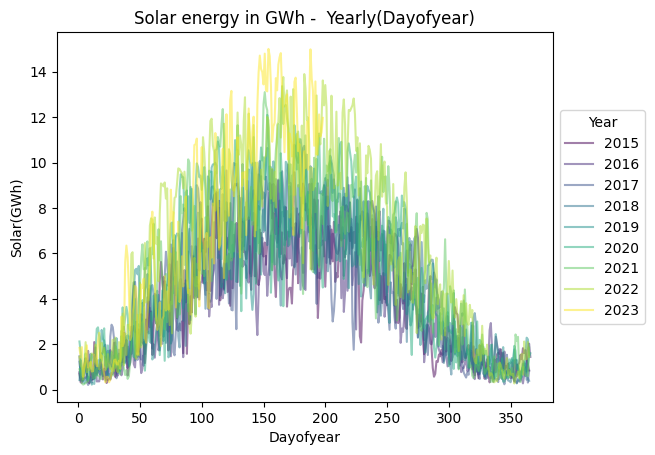

In [502]:
# Plot yearly seasonality
fig, ax = plt.subplots() 

pd.pivot_table(data=daily_data_df[['Year', 'Dayofyear', target]], index='Dayofyear', columns='Year') \
    [target] \
    .plot(cmap='viridis', alpha=0.5, ax=ax)

ax.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set(title= title_main +' '+'-'+' ' + ' ' +'Yearly(Dayofyear)', ylabel=ylable_target);
#fig.savefig("visualisations/total_energy_generation_mwh.png",dpi=300)

In [503]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Dayofyear', group='Year')

In [504]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr =  ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Month', group='Year')

In [505]:
df_c = data_df.copy()

In [506]:
def combine_date_and_time(df, date_column='Date', time_column='Hour', target_column=target):
    # Convert 'Date' column to datetime format
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Combine 'Date' and 'Hour' columns to create the 'Datetime' column
    df['Datetime'] = df.apply(lambda row: row[date_column] + pd.Timedelta(hours=row[time_column]), axis=1)
    
    # Select the desired columns for the final DataFrame
    df_result  = df[['Datetime', target_column]]
    
    return df_result

In [507]:
#print(dfs.shape)
#plt.figure()
#plt.plot(dfs['Date'], dfs[target])
#plt.autoscale(enable=True, axis='x', tight=True)
#plt.show();

In [508]:
df_dt = combine_date_and_time(df_c, date_column='Date', time_column='Hour', target_column=target)
df_dt.head()

,Datetime,Solar_gwh
0,2015-01-01 00:00:00,0.0
1,2015-01-01 01:00:00,0.0
2,2015-01-01 02:00:00,0.0
3,2015-01-01 03:00:00,0.0
4,2015-01-01 04:00:00,0.0


<Axes: xlabel='Datetime'>

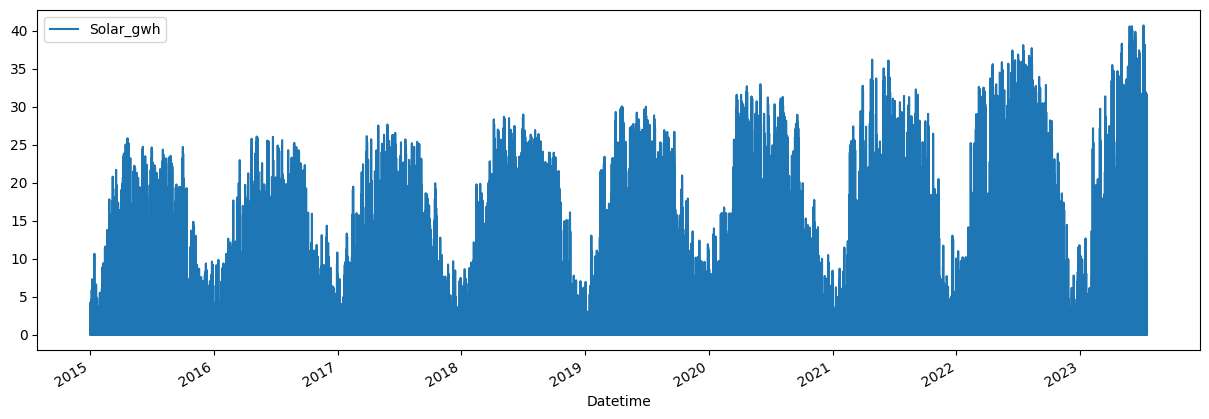

In [509]:
df_dt = df_dt.set_index('Datetime')
df_dt.plot(style = '-', figsize = (15,5), color='#1f76b4')

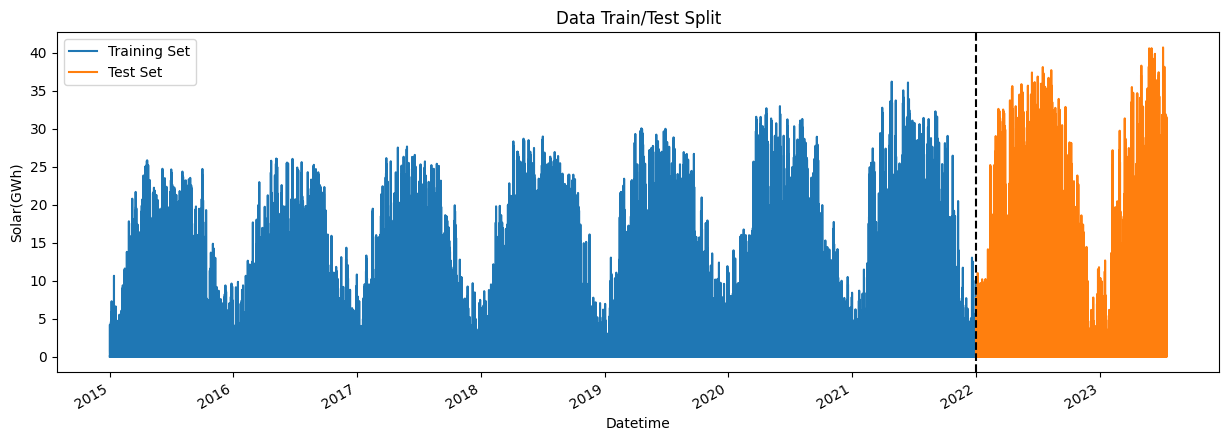

In [510]:
#df_c = pd.DataFrame(df_c.index)
#df_c.index
train =  df_dt.loc[df_dt.index < '2022-01-1']
test =  df_dt.loc[df_dt.index >= '2022-01-1']
fig, ax = plt.subplots(figsize=(15,5))
train.plot(ax=ax, label = 'Training Set', title= 'Data Train/Test Split')
test.plot (ax=ax, ylabel=ylable_target, label = 'Test Set')
ax.axvline('2022-01-1', color = 'black', ls= '--')
ax.legend(['Training Set','Test Set'])
#ax.ylabel(target)
plt.show()

In [511]:
def create_features(df):
    """
    create time series features based on time series index 
    """
    df['Hour'] = df.index.hour
    df['Year'] = df.index.year
    df['Month'] = df.index.month
    #df['Week'] = df.index.week
    #df['Week'] = df.index.weekofyear  # Use weekofyear instead of week
    df['Day'] = df.index.day
    #df['Dayofyear'] = df.index.dayofyear
    return df
df_dt = create_features(df_dt)
df_dt.head()

,Solar_gwh,Hour,Year,Month,Day
Datetime,,,,,
2015-01-01 00:00:00,0.0,0,2015,1,1
2015-01-01 01:00:00,0.0,1,2015,1,1
2015-01-01 02:00:00,0.0,2,2015,1,1
2015-01-01 03:00:00,0.0,3,2015,1,1
2015-01-01 04:00:00,0.0,4,2015,1,1


In [512]:
#features= ['Hour','Year', 'Month', 'Day']# 

In [513]:
#train = create_features(train)
#test = create_features(test)
#dfs = data_df[['Date',  target]]#train.head()

In [514]:
data_df.columns

Index(['Area', 'Mtu', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Date', 'Hour', 'Total_energy_generation_gwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh', 'Year',
       'Month', 'Day', 'Dayofyear'],
      dtype='object')

## Univariate time series  for LSTM for  forecasting

In [429]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

def lstm_model(target, data_df, lookback=12, sampling_frequency='M'):
    # Prepare the input data
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    if sampling_frequency:
        dfs = data_df[['Date', target]]
        dfs['Date'] = pd.to_datetime(dfs['Date'])
        dfs.set_index('Date', inplace=True)
        dfs_resampled = dfs.resample(sampling_frequency).mean()
    else:
        dfs_resampled = data_df
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs_resampled[target].values.reshape(-1, 1))
    
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.8)
    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size-lookback:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size-lookback:]
    
    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_train_lstm, y_train_lstm, epochs=100, batch_size=30, validation_data=(X_test_lstm, y_test_lstm), verbose=1)
    
    # LSTM prediction on test and train data
    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    # Inverse transform the scaled data to get the original scale
    y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm)
    y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm)
    y_train_lstm = scaler.inverse_transform(y_train_lstm)
    y_test_lstm = scaler.inverse_transform(y_test_lstm)
    
    # Compute metrics for LSTM
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
    train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
    test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
    train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
    test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
    train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
    test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)
    
    # Calculate residuals
    residuals = y_test_lstm - y_pred_test_lstm
    
    # Plot loss versus epoch and validation loss versus epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()
    
    # Create a residual plot
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()
    
    # Plot actual vs. predicted values
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm, y_pred_test_lstm, label='', color='blue')
    plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()
    
    # Plot actual, train data, and predicted test data for LSTM
    plt.figure(figsize=(15, 5))
    train_index = dfs_resampled.index[:train_size][-len(y_train_lstm):]
    test_index = dfs_resampled.index[train_size:]
    plt.plot(dfs_resampled.index, dfs_resampled[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.legend()
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()
    
    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape)

    return {
        'train_rmse': train_rmse,
        'train_mse': train_mse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'residuals': residuals,
        'y_test_predicted': y_pred_test_lstm,
    }


In [ ]:
# Assuming 'data_df' is your input DataFrame containing the processing data
results = lstm_model('Wind_offshore_gwh', data_df, lookback=12, sampling_frequency='M')
#results = lstm_model('Total_other_renewable_gwh', data_df, lookback=12, sampling_frequency='D')

#### LSTM including rolling mean and detrend

In [452]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

def detrend_data(data, window):
    detrended = data.rolling(window=window, min_periods=1, center=True).mean()
    detrended = detrended.fillna(method='bfill')
    return detrended

def lstm_model_fancy(target, data_df, lookback=12, sampling_frequency='M', rolling_mean=None, detrend=False, moving_average=False, ma_window=None):
    # Prepare the input data
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    if sampling_frequency:
        dfs = data_df[['Date', target]]
        dfs['Date'] = pd.to_datetime(dfs['Date'])
        dfs.set_index('Date', inplace=True)
        dfs_resampled = dfs.resample(sampling_frequency).mean()
    else:
        dfs_resampled = data_df
    
    if rolling_mean:
        dfs_resampled[target] = dfs_resampled[target].rolling(window=rolling_mean, min_periods=1, center=True).mean()
        dfs_resampled[target] = dfs_resampled[target].fillna(method='bfill')
    
    if detrend:
        result = seasonal_decompose(dfs_resampled[target], model='additive', period=12)
        dfs_resampled[target] = dfs_resampled[target] - result.trend
        dfs_resampled[target] = dfs_resampled[target].fillna(method='bfill')
    
    if moving_average:
        dfs_resampled[target] = dfs_resampled[target].rolling(window=ma_window, min_periods=1, center=True).mean()
        dfs_resampled[target] = dfs_resampled[target].fillna(method='bfill')
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs_resampled[target].values.reshape(-1, 1))
    
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.8)
    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size-lookback:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size-lookback:]
    
    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_train_lstm, y_train_lstm, epochs=30, batch_size=5, validation_data=(X_test_lstm, y_test_lstm), verbose=1)
    
    # LSTM prediction on test and train data
    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    # Inverse transform the scaled data to get the original scale
    y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm)
    y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm)
    y_train_lstm = scaler.inverse_transform(y_train_lstm)
    y_test_lstm = scaler.inverse_transform(y_test_lstm)
    
    # Compute metrics for LSTM
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
    train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
    test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
    train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
    test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
    train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
    test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)
    
    # Calculate residuals
    residuals = y_test_lstm - y_pred_test_lstm
    
    # Plot loss versus epoch and validation loss versus epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()
    
    # Create a residual plot
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()
    
    # Plot actual vs. predicted values
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm, y_pred_test_lstm, label='', color='blue')
    plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()
    
    # Plot actual, train data, and predicted test data for LSTM
    plt.figure(figsize=(15, 5))
    train_index = dfs_resampled.index[:train_size][-len(y_train_lstm):]
    test_index = dfs_resampled.index[train_size:]
    plt.plot(dfs_resampled.index, dfs_resampled[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.legend()
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()
    
    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape)

    return {
        'train_rmse': train_rmse,
        'train_mse': train_mse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'residuals': residuals,
        'y_test_predicted': y_pred_test_lstm,
    }



- The min_periods and center parameters are optional arguments used in the rolling() method of Pandas DataFrame. They control how the rolling window behaves at the beginning and end of the data when there are fewer data points than the specified window size.

- min_periods: This parameter sets the minimum number of valid data points required to calculate the rolling window result. By default, it is set to None, which means the rolling window will only be calculated when the window is entirely filled with valid data points. When min_periods is set to an integer value, the rolling window calculation will start from the first data point for which at least min_periods valid data points are available. In the context of the LSTM model, it is used to handle the missing data at the beginning of the rolling window.

- center: When center is set to True, the calculated result is assigned to the center of the window. This means the result at each time step is associated with the middle value of the window. If center is set to False, the calculated result will be assigned to the right-most value of the window, aligning the result with the end of the window. The default value for center is False.
Here's an example of how to set these parameters in the rolling() method:

In [450]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

def detrend_data(data, window):
    detrended = data.rolling(window=window, min_periods=1, center=True).mean()
    detrended = detrended.fillna(method='bfill')
    return detrended

def lstm_model_seasnol(data, target, lookback=12):
    # Prepare the input data
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(data[target].values.reshape(-1, 1))
    
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.8)
    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size-lookback:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size-lookback:]
    
    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_train_lstm, y_train_lstm, epochs=10, batch_size=3, validation_data=(X_test_lstm, y_test_lstm), verbose=1)
    
    # LSTM prediction on test and train data
    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    # Inverse transform the scaled data to get the original scale
    y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm)
    y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm)
    y_train_lstm = scaler.inverse_transform(y_train_lstm)
    y_test_lstm = scaler.inverse_transform(y_test_lstm)
    
    # Compute metrics for LSTM
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
    train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
    test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
    train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
    test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
    train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
    test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)
    
    # Calculate residuals
    residuals = y_test_lstm - y_pred_test_lstm
    
    # Plot loss versus epoch and validation loss versus epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()
    
    # Create a residual plot
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()
    
    # Plot actual vs. predicted values
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm, y_pred_test_lstm, label='', color='blue')
    plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()
    
    # Plot actual, train data, and predicted test data for LSTM
    plt.figure(figsize=(15, 5))
    train_index = data.index[:train_size][-len(y_train_lstm):]
    test_index = data.index[train_size:]
    plt.plot(data.index, data[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.legend()
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()
    
    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, data.shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, data.shape)

    return {
        'train_rmse': train_rmse,
        'train_mse': train_mse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'residuals': residuals,
        'y_test_predicted': y_pred_test_lstm,
    }


def preprocess_data(data, target, freq='M', rolling_mean=None, detrend=False):
    df = data.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

    if freq:
        df_resampled = df.resample(freq).mean()
    else:
        df_resampled = df

    if rolling_mean:
        df_resampled[target] = df_resampled[target].rolling(window=rolling_mean, min_periods=1, center=True).mean()
        # Fill NaN values after rolling mean
        df_resampled[target] = df_resampled[target].fillna(method='bfill')

    if detrend:
        result = seasonal_decompose(df_resampled[target], model='additive', period=12)
        df_resampled[target] = df_resampled[target] - result.trend
        # Fill NaN values after detrending
        df_resampled[target] = df_resampled[target].fillna(method='bfill')

    # Check for NaN values after preprocessing steps
    print("NaN values in target column after preprocessing:", df_resampled[target].isnull().sum())

    # Plot seasonality, trend, detrend, and stationarity over time
    plt.figure(figsize=(15, 10))
    plt.subplot(4, 1, 1)
    plt.plot(df_resampled[target], label='Original Data', color='blue')
    plt.legend()
    plt.title('Original Data')

    plt.subplot(4, 1, 2)
    plt.plot(result.trend, label='Trend', color='red')
    plt.legend()
    plt.title('Trend')

    plt.subplot(4, 1, 3)
    plt.plot(result.seasonal, label='Seasonality', color='green')
    plt.legend()
    plt.title('Seasonality')

    plt.subplot(4, 1, 4)
    plt.plot(df_resampled[target] - result.trend - result.seasonal, label='Detrended and Stationary Data', color='orange')
    plt.legend()
    plt.title('Detrended and Stationary Data')

    plt.tight_layout()
    plt.show()

    return df_resampled

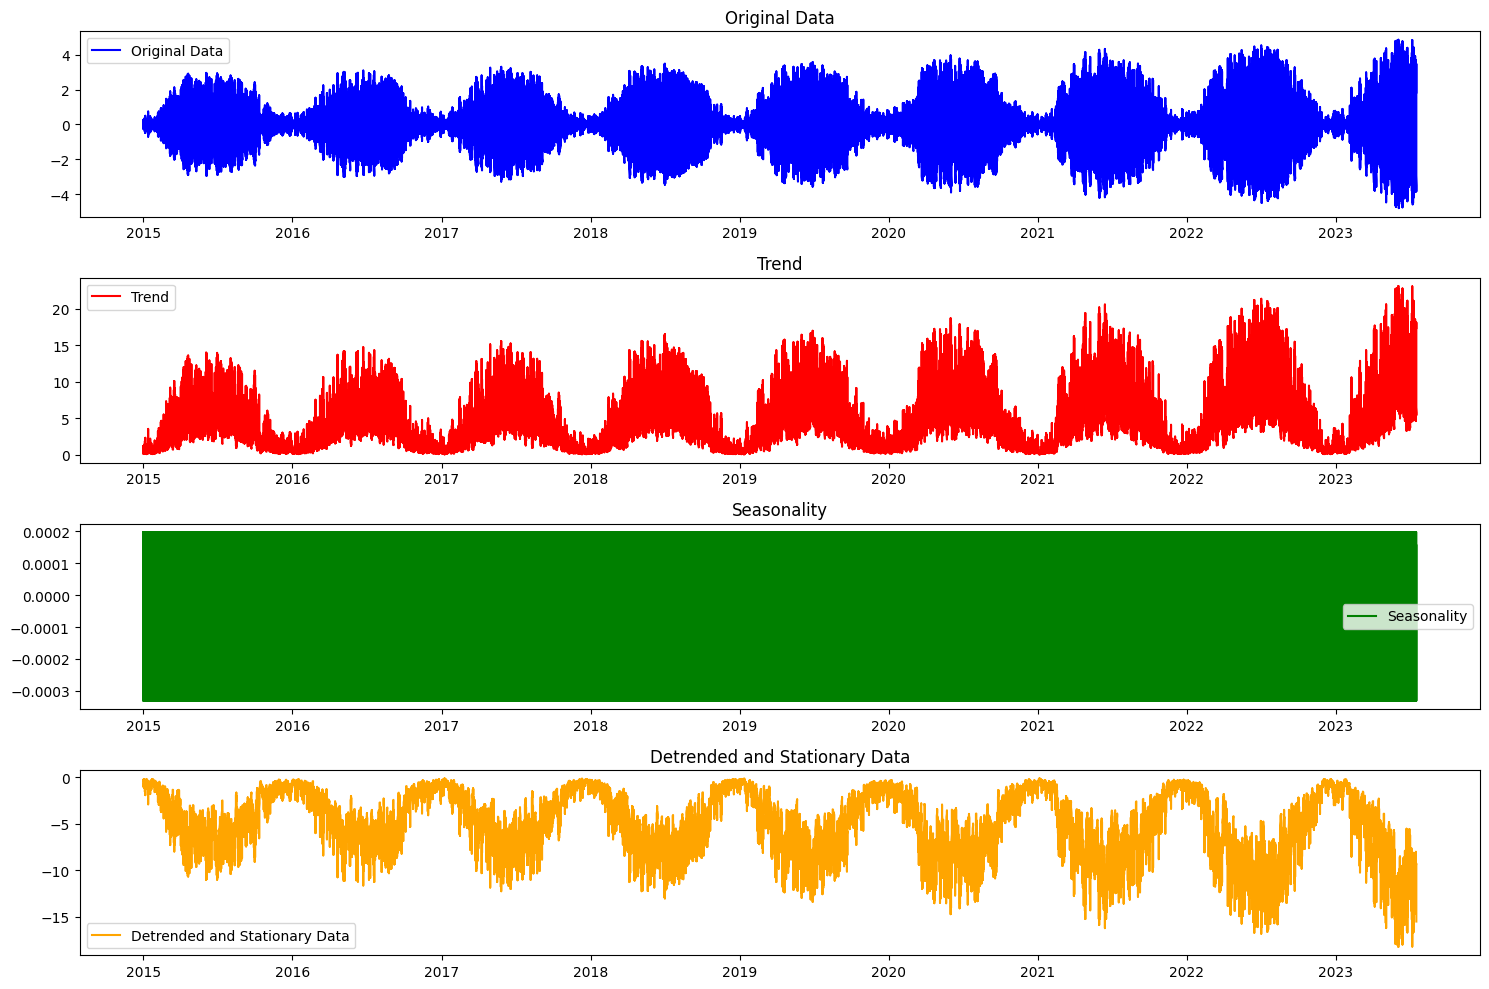

Epoch 1/10
19967/19967 [==============================] - 41s 2ms/step - loss: 7.7348e-04 - val_loss: nan
Epoch 2/10
19967/19967 [==============================] - 40s 2ms/step - loss: 1.3838e-05 - val_loss: nan
Epoch 3/10
19967/19967 [==============================] - 42s 2ms/step - loss: 6.7544e-06 - val_loss: nan
Epoch 4/10
19967/19967 [==============================] - 40s 2ms/step - loss: 4.6638e-06 - val_loss: nan
Epoch 5/10
19967/19967 [==============================] - 40s 2ms/step - loss: 3.9840e-06 - val_loss: nan
Epoch 6/10
19967/19967 [==============================] - 42s 2ms/step - loss: 3.5667e-06 - val_loss: nan
Epoch 7/10
19967/19967 [==============================] - 43s 2ms/step - loss: 3.2188e-06 - val_loss: nan
Epoch 8/10
19967/19967 [==============================] - 43s 2ms/step - loss: 3.0212e-06 - val_loss: nan
Epoch 9/10
19967/19967 [==============================] - 47s 2ms/step - loss: 2.8595e-06 - val_loss: nan
Epoch 10/10
469/469 [=========================

ValueError: Input contains NaN.

In [451]:

# Choose the target variable for forecasting
target = 'Solar_gwh'
preprocessed_data = preprocess_data(data_df, target, freq=None, rolling_mean=5, detrend=True)
# Perform LSTM forecasting on the preprocessed data
forecast_results = lstm_model_seasnol(preprocessed_data, target, lookback=5)

In [ ]:
# Assuming 'data_df' is your input DataFrame containing the processing data
# Set detrend=True and sampling_frequency (set to None) as follows:
results = lstm_model('Wind_offshore_gwh', data_df, lookback=12, sampling_frequency=None, rolling_mean=None, detrend=True, moving_average=False)


Epoch 1/100
1997/1997 [==============================] - 11s 5ms/step - loss: 0.0015 - val_loss: 1.9164e-04
Epoch 2/100
1997/1997 [==============================] - 9s 5ms/step - loss: 6.6375e-05 - val_loss: 8.4271e-05
Epoch 3/100
1997/1997 [==============================] - 9s 5ms/step - loss: 3.1140e-05 - val_loss: 3.1846e-05
Epoch 4/100
1997/1997 [==============================] - 10s 5ms/step - loss: 1.5269e-05 - val_loss: 1.2373e-05
Epoch 5/100
1997/1997 [==============================] - 10s 5ms/step - loss: 1.0831e-05 - val_loss: 1.3922e-05
Epoch 6/100
1997/1997 [==============================] - 10s 5ms/step - loss: 7.5163e-06 - val_loss: 7.1326e-06
Epoch 7/100
1997/1997 [==============================] - 9s 5ms/step - loss: 5.6507e-06 - val_loss: 7.6637e-06
Epoch 8/100
1997/1997 [==============================] - 9s 5ms/step - loss: 4.5517e-06 - val_loss: 8.0398e-06
Epoch 9/100
1997/1997 [==============================] - 9s 5ms/step - loss: 4.0779e-06 - val_loss: 6.3344e-06
E

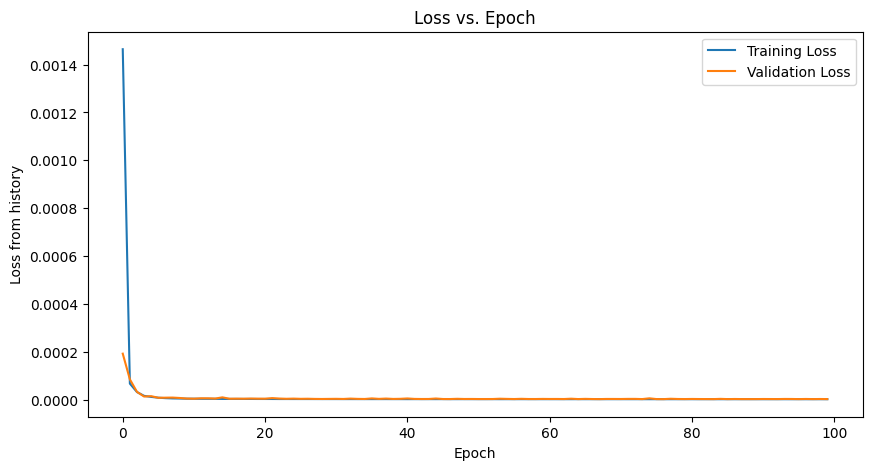

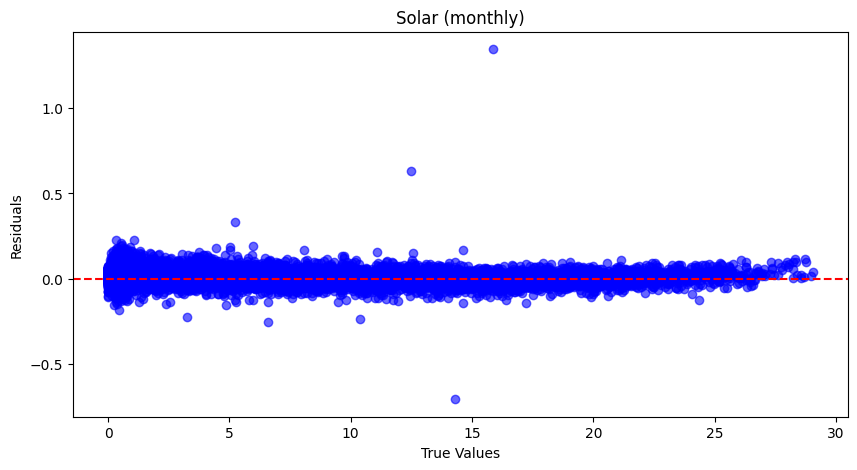

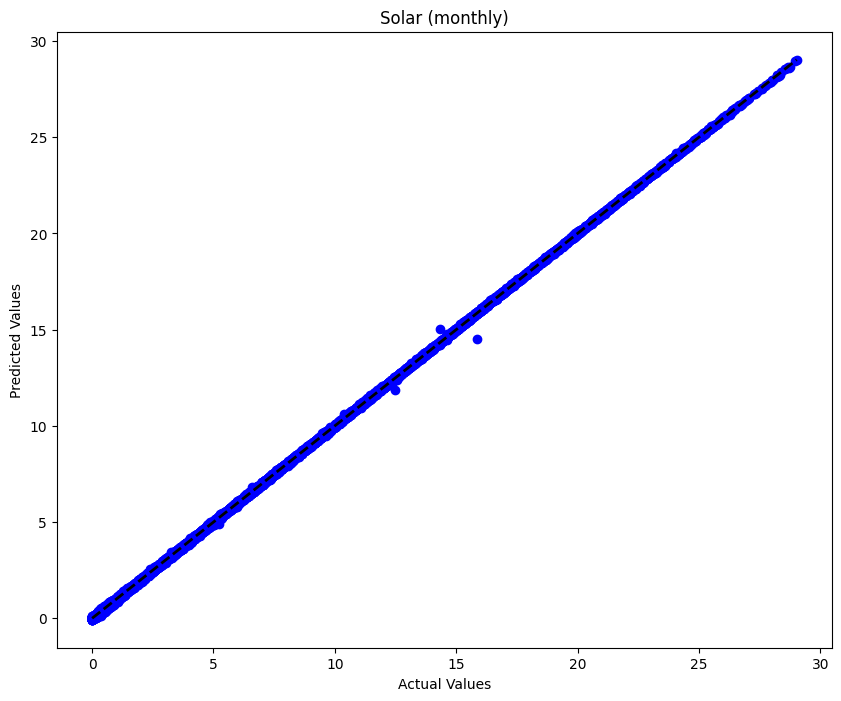

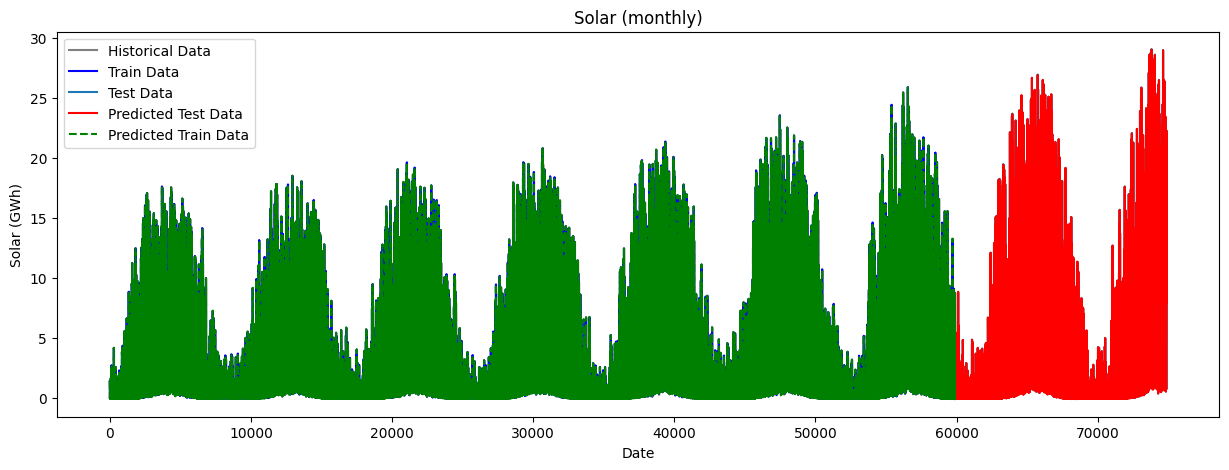

Train RMSE: 0.029625724605977656
Train MSE: 0.00087768355842923
Train MAE: 0.021974759660319577
Train R2 Score: 0.9999624258864435
Test RMSE: 0.0386343872354141
Test MSE: 0.0014926158770559278
Test MAE: 0.026595514073736205
Test R2 Score: 0.9999656079221069
X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape = (59893, 12, 1) (14986, 12, 1) (59893, 1) (14986, 1) (74867, 12, 1) (74867, 1) (74879, 33)


In [435]:
# Assuming 'data_df' is your input DataFrame containing the processing data
# Set rolling_mean and sampling_frequency (set to None) as follows:
results = lstm_model_fancy('Solar_gwh', data_df, lookback=12, sampling_frequency=None, rolling_mean=12, detrend=False, moving_average=False)

Epoch 1/100


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_74360/3998490672.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


3/3 [==============================] - 1s 89ms/step - loss: 0.2586 - val_loss: 0.3262
Epoch 2/100
3/3 [==============================] - 0s 13ms/step - loss: 0.2332 - val_loss: 0.2904
Epoch 3/100
3/3 [==============================] - 0s 11ms/step - loss: 0.2055 - val_loss: 0.2478
Epoch 4/100
3/3 [==============================] - 0s 11ms/step - loss: 0.1732 - val_loss: 0.1982
Epoch 5/100
3/3 [==============================] - 0s 11ms/step - loss: 0.1353 - val_loss: 0.1406
Epoch 6/100
3/3 [==============================] - 0s 10ms/step - loss: 0.0908 - val_loss: 0.0810
Epoch 7/100
3/3 [==============================] - 0s 10ms/step - loss: 0.0502 - val_loss: 0.0514
Epoch 8/100
3/3 [==============================] - 0s 10ms/step - loss: 0.0382 - val_loss: 0.0930
Epoch 9/100
3/3 [==============================] - 0s 10ms/step - loss: 0.0536 - val_loss: 0.0716
Epoch 10/100
3/3 [==============================] - 0s 10ms/step - loss: 0.0382 - val_loss: 0.0529
Epoch 11/100
3/3 [=============

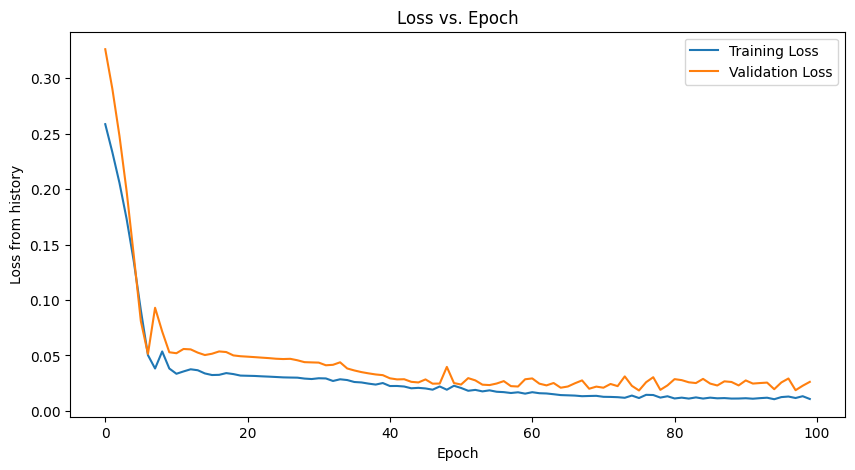

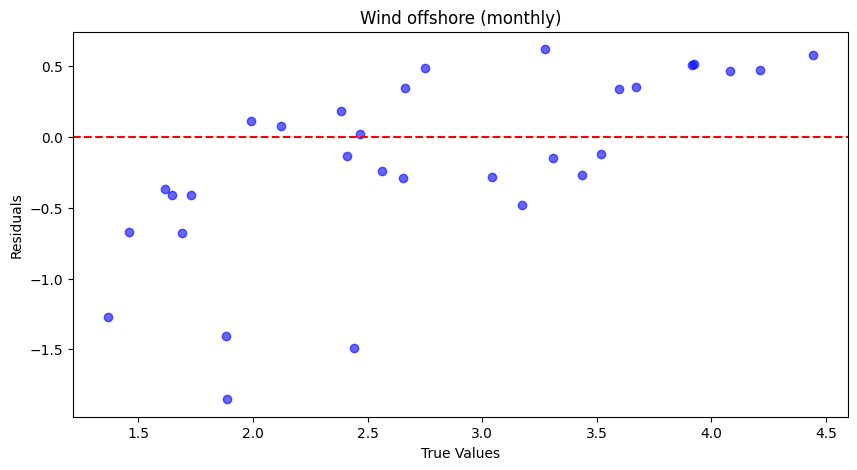

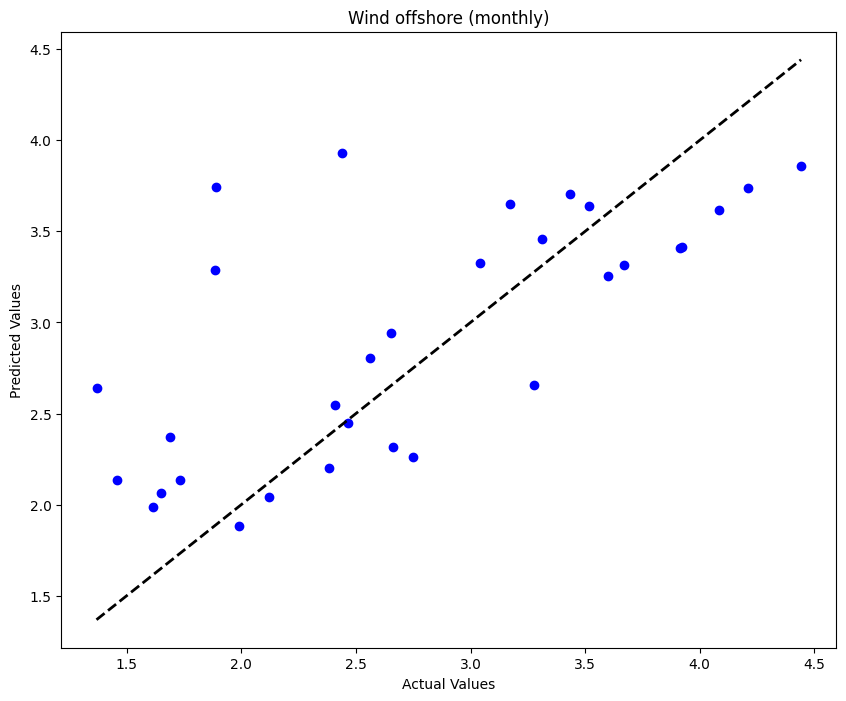

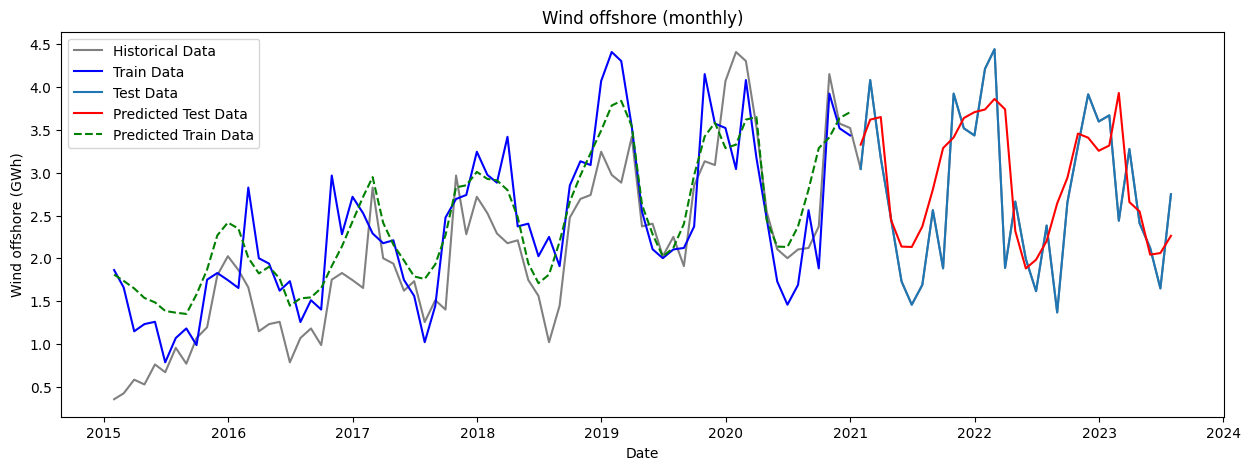

Train RMSE: 0.42722474839627905
Train MSE: 0.18252098564226393
Train MAE: 0.3323982420407303
Train R2 Score: 0.7667429659213647
Test RMSE: 0.6609536335516458
Test MSE: 0.4368597057051233
Test MAE: 0.5031796856487122
Test R2 Score: 0.43957872295300704
X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape = (72, 12, 1) (31, 12, 1) (72, 1) (31, 1) (91, 12, 1) (91, 1) (103, 1)


In [433]:
# Assuming 'data_df' is your input DataFrame containing the processing data
results = lstm_model('Wind_offshore_gwh', data_df, lookback=12, sampling_frequency='M')
#results = lstm_model('Total_other_renewable_gwh', data_df, lookback=12, sampling_frequency='D')

Epoch 1/100
1996/1996 [==============================] - 23s 11ms/step - loss: 0.0034 - val_loss: 0.0016
Epoch 2/100
1996/1996 [==============================] - 21s 10ms/step - loss: 8.1080e-04 - val_loss: 0.0015
Epoch 3/100
1996/1996 [==============================] - 21s 11ms/step - loss: 7.8109e-04 - val_loss: 0.0017
Epoch 4/100
1996/1996 [==============================] - 22s 11ms/step - loss: 7.6418e-04 - val_loss: 0.0015
Epoch 5/100
1996/1996 [==============================] - 21s 11ms/step - loss: 7.4540e-04 - val_loss: 0.0015
Epoch 6/100
1996/1996 [==============================] - 22s 11ms/step - loss: 7.3592e-04 - val_loss: 0.0015
Epoch 7/100
1996/1996 [==============================] - 22s 11ms/step - loss: 7.3245e-04 - val_loss: 0.0016
Epoch 8/100
1996/1996 [==============================] - 21s 10ms/step - loss: 7.2744e-04 - val_loss: 0.0016
Epoch 9/100
1996/1996 [==============================] - 21s 11ms/step - loss: 7.2664e-04 - val_loss: 0.0015
Epoch 10/100
1996/1996 

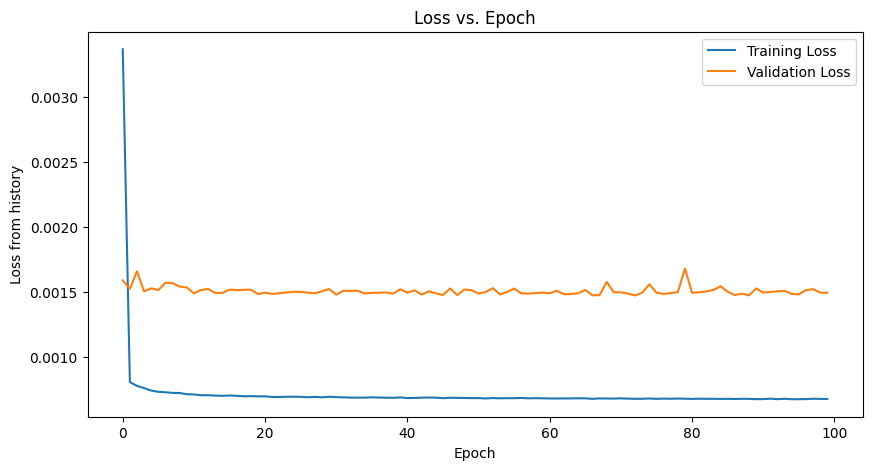

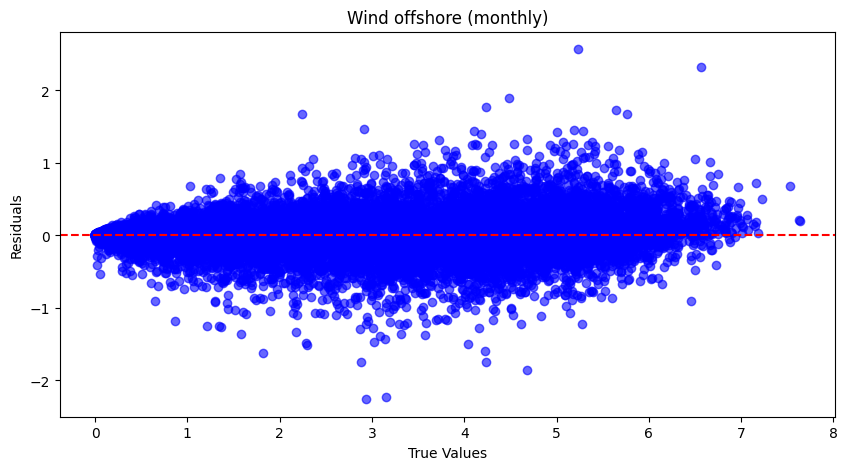

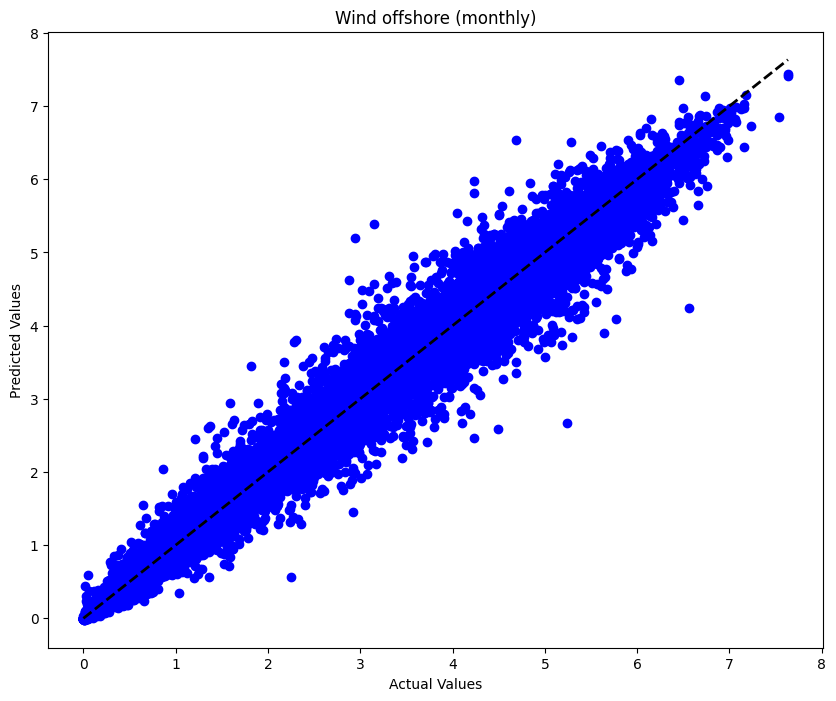

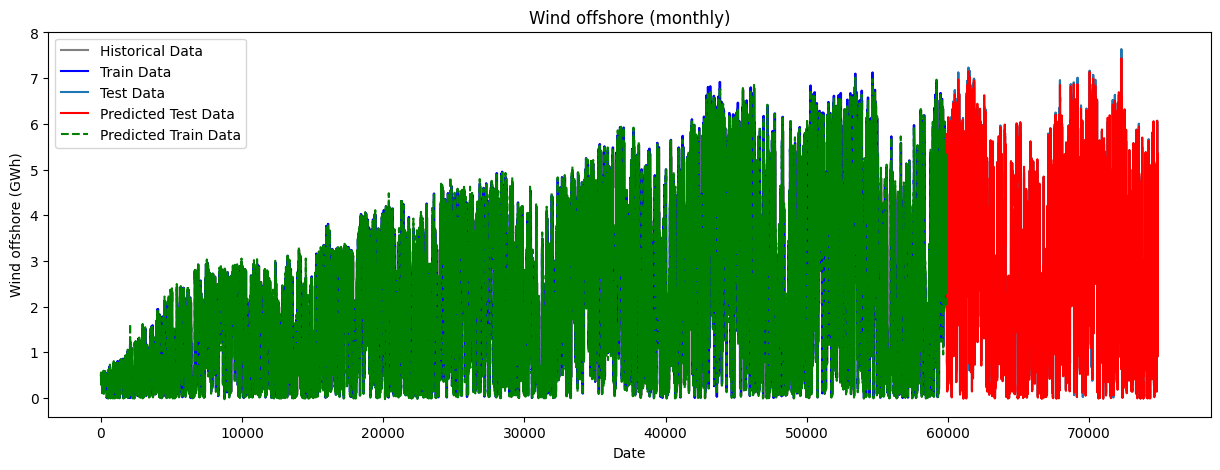

Train RMSE: 0.19774090721252052
Train MSE: 0.03910146638523065
Train MAE: 0.12786815166535231
Train R2 Score: 0.9862060659075607
Test RMSE: 0.2952551492739343
Test MSE: 0.08717560317277324
Test MAE: 0.2038663594773823
Test R2 Score: 0.975294625512996
X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape = (59879, 30, 1) (15000, 30, 1) (59879, 1) (15000, 1) (74849, 30, 1) (74849, 1) (74879, 33)


In [453]:
results = lstm_model('Wind_offshore_gwh', data_df, lookback=30, sampling_frequency=None)

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_74360/3998490672.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/100
83/83 [==============================] - 2s 9ms/step - loss: 0.0537 - val_loss: 0.0545
Epoch 2/100
83/83 [==============================] - 0s 6ms/step - loss: 0.0382 - val_loss: 0.0520
Epoch 3/100
83/83 [==============================] - 0s 6ms/step - loss: 0.0366 - val_loss: 0.0504
Epoch 4/100
83/83 [==============================] - 0s 6ms/step - loss: 0.0353 - val_loss: 0.0474
Epoch 5/100
83/83 [==============================] - 0s 6ms/step - loss: 0.0324 - val_loss: 0.0422
Epoch 6/100
83/83 [==============================] - 0s 6ms/step - loss: 0.0304 - val_loss: 0.0405
Epoch 7/100
83/83 [==============================] - 0s 6ms/step - loss: 0.0296 - val_loss: 0.0402
Epoch 8/100
83/83 [==============================] - 0s 6ms/step - loss: 0.0282 - val_loss: 0.0394
Epoch 9/100
83/83 [==============================] - 0s 6ms/step - loss: 0.0277 - val_loss: 0.0417
Epoch 10/100
83/83 [==============================] - 0s 6ms/step - loss: 0.0277 - val_loss: 0.0404
Epoch 11/

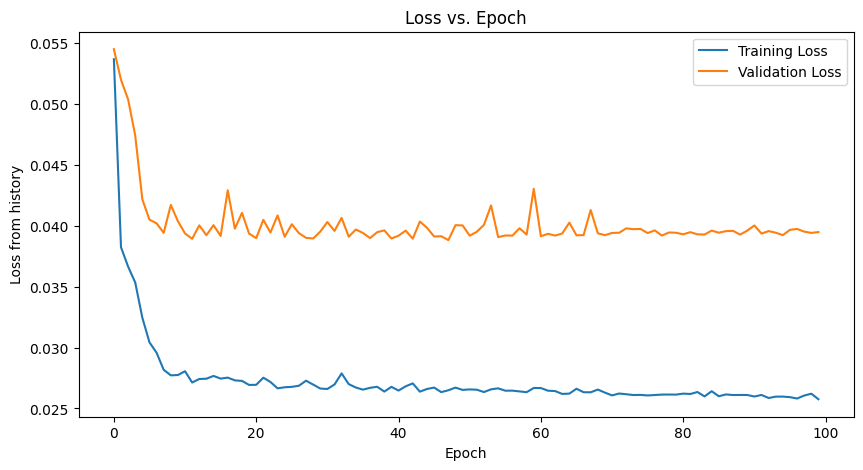

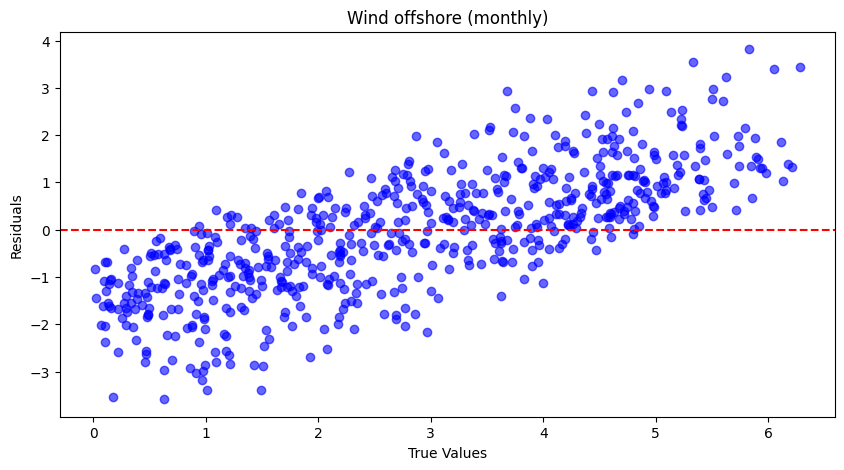

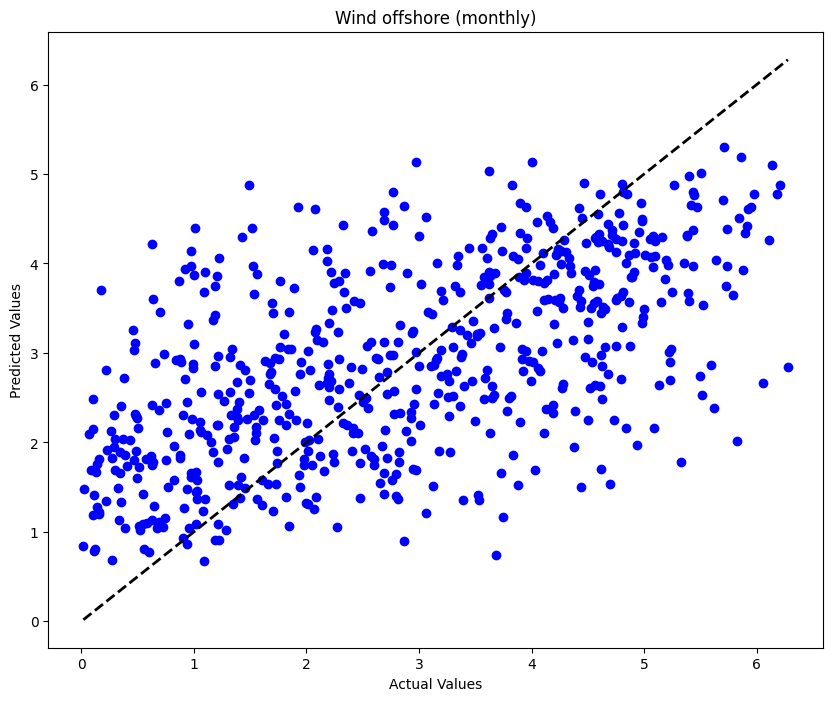

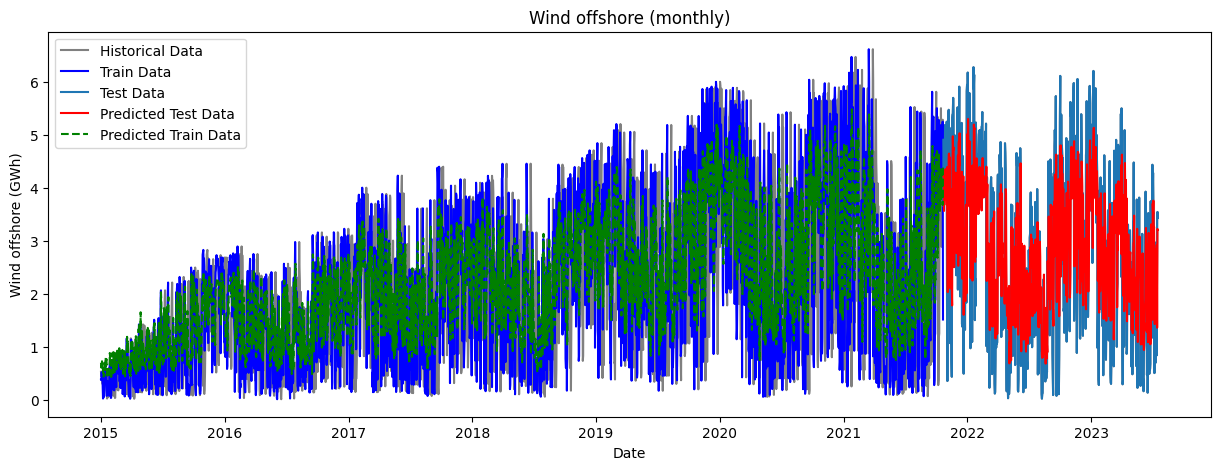

Train RMSE: 1.0595342362016684
Train MSE: 1.122612797683453
Train MAE: 0.8373156517966284
Train R2 Score: 0.5121002413096107
Test RMSE: 1.3135060777049594
Test MSE: 1.7252982161678667
Test MAE: 1.0544339950392219
Test R2 Score: 0.35214255111597625
X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape = (2486, 12, 1) (634, 12, 1) (2486, 1) (634, 1) (3108, 12, 1) (3108, 1) (3120, 1)


In [430]:
# Assuming 'data_df' is your input DataFrame containing the processing data
results = lstm_model('Wind_offshore_gwh', data_df, lookback=12, sampling_frequency='D')

## Multivariate LSTM forecasting

#### correct code 

In [ ]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback, :-1])
        y.append(data[i+lookback, -1])
    return np.array(X), np.array(y)

def lstm_mlvrt(target, data_df, features, lookback=12, sampling_frequency='M', rolling_mean=None, detrend=False, moving_average=False, ma_window=None):
    # Prepare the input data
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    if sampling_frequency:
        data_df['Date'] = pd.to_datetime(data_df['Date'])
        data_df.set_index('Date', inplace=True)
        dfs_resampled = data_df[features + [target]].resample(sampling_frequency).mean()
    else:
        dfs_resampled = data_df[features + [target]]
    
    if rolling_mean:
        for feature in features + [target]:
            dfs_resampled[feature] = dfs_resampled[feature].rolling(window=rolling_mean, min_periods=1, center=True).mean()
            dfs_resampled[feature] = dfs_resampled[feature].fillna(method='bfill')
    
    if detrend:
        result = seasonal_decompose(dfs_resampled[target], model='additive', period=12)
        dfs_resampled[target] = dfs_resampled[target] - result.trend
        dfs_resampled[target] = dfs_resampled[target].fillna(method='bfill')
    
    if moving_average:
        for feature in features + [target]:
            dfs_resampled[feature] = dfs_resampled[feature].rolling(window=ma_window, min_periods=1, center=True).mean()
            dfs_resampled[feature] = dfs_resampled[feature].fillna(method='bfill')
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs_resampled.values)
    
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    # Set the train-test split to be 80-20%
    train_size = int(len(X_lstm) * 0.8)
    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size-lookback:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size-lookback:]
    
    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, len(features)), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_train_lstm, y_train_lstm, epochs=30, batch_size=5, validation_data=(X_test_lstm, y_test_lstm), verbose=1)
    
    # LSTM prediction on test and train data
    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    # Inverse transform the scaled data to get the original scale
    y_pred_train_lstm = scaler.inverse_transform(np.hstack((X_train_lstm[:, -1, :], y_pred_train_lstm)))
    y_pred_test_lstm = scaler.inverse_transform(np.hstack((X_test_lstm[:, -1, :], y_pred_test_lstm)))
    y_train_lstm = scaler.inverse_transform(np.hstack((X_train_lstm[:, -1, :], y_train_lstm.reshape(-1, 1))))
    y_test_lstm = scaler.inverse_transform(np.hstack((X_test_lstm[:, -1, :], y_test_lstm.reshape(-1, 1))))
    
    # Compute metrics for LSTM
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1]))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1]))
    train_mse = mean_squared_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_mse = mean_squared_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    train_mae = mean_absolute_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_mae = mean_absolute_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    train_r2 = r2_score(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_r2 = r2_score(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    
    # Calculate residuals
    residuals = y_test_lstm[:, -1] - y_pred_test_lstm[:, -1]

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    # Plot loss versus epoch and validation loss versus epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()
    
    # Create a residual plot
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm[:, -1], residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()
    
    # Plot actual vs. predicted values
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm[:, -1], y_pred_test_lstm[:, -1], label='', color='blue')
    plt.plot([y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], [y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()
    
    # Plot actual, train data, and predicted test data for LSTM
    plt.figure(figsize=(15, 5))
    train_index = dfs_resampled.index[:train_size][-len(y_train_lstm):]
    test_index = dfs_resampled.index[-len(y_test_lstm):]  # Ensure test_index and y_test_lstm have the same length
    plt.plot(dfs_resampled.index, dfs_resampled[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm[:, -1], label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm[:, -1], label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm[:, -1], label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm[:, -1], label='Predicted Train Data', color='green', linestyle='dashed')
    # Draw a vertical line between train and test split
    plt.axvline(train_index[-1], color='k', linestyle='--')
    plt.legend()
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()

    #print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape)

    return {
        'train_rmse': train_rmse,
        'train_mse': train_mse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'residuals': residuals,
        'y_test_predicted': y_pred_test_lstm,
        'model': model,
        'X_train_lstm': X_train_lstm,
        'X_test_lstm': X_test_lstm
    }


In [ ]:
data = data_df.copy()

In [ ]:
target = 'Total_energy_generation_gwh'
features = ['Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh']  # You can add other features if needed
result = lstm_mlvrt(target, data, features=features, lookback=12, sampling_frequency='M',
                    rolling_mean=None, detrend=False, moving_average=False, ma_window=None)

In [538]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

def detrend_data(data, window):
    detrended = data.rolling(window=window, min_periods=1, center=True).mean()
    detrended = detrended.fillna(method='bfill')
    return detrended

def lstm_mlvrt(target, data_df, features, lookback=12, sampling_frequency='M', rolling_mean=None, detrend=False, moving_average=False, ma_window=None):
    # Prepare the input data
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')

    dfs = data_df[['Date', target] + features]
    dfs['Date'] = pd.to_datetime(dfs['Date'])
    dfs.set_index('Date', inplace=True)
    dfs_resampled = dfs.resample(sampling_frequency).mean()

    if rolling_mean:
        dfs_resampled[target] = dfs_resampled[target].rolling(window=rolling_mean, min_periods=1, center=True).mean()
        dfs_resampled[target] = dfs_resampled[target].fillna(method='bfill')

    if detrend:
        result = seasonal_decompose(dfs_resampled[target], model='additive', period=12)
        dfs_resampled[target] = dfs_resampled[target] - result.trend
        dfs_resampled[target] = dfs_resampled[target].fillna(method='bfill')

    if moving_average:
        dfs_resampled[target] = dfs_resampled[target].rolling(window=ma_window, min_periods=1, center=True).mean()
        dfs_resampled[target] = dfs_resampled[target].fillna(method='bfill')

    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs_resampled[[target] + features].values)

    X_lstm, y_lstm = create_sequences(data_scaled, lookback)

    train_size = int(len(X_lstm) * 0.8)
    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size:]

    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, len(features))))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_train_lstm, y_train_lstm, epochs=30, batch_size=5, validation_data=(X_test_lstm, y_test_lstm), verbose=1)

    # LSTM prediction on test and train data
    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)

    # Inverse transform the scaled data to get the original scale
    y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm)
    y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm)
    y_train_lstm = scaler.inverse_transform(y_train_lstm)
    y_test_lstm = scaler.inverse_transform(y_test_lstm)

    # Compute metrics for LSTM
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
    train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
    test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
    train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
    test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
    train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
    test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)

    # Calculate residuals
    residuals = y_test_lstm - y_pred_test_lstm


    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    # Plot loss versus epoch and validation loss versus epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()

    # Create a residual plot
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()

    # Plot actual vs. predicted values
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm, y_pred_test_lstm, label='', color='blue')
    plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()

    # Plot actual, train data, and predicted test data for LSTM
    plt.figure(figsize=(15, 5))
    train_index = dfs_resampled.index[:train_size][-len(y_train_lstm):]
    test_index = dfs_resampled.index[train_size:]
    plt.plot(dfs_resampled.index, dfs_resampled[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.legend()
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()


    #print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape)

    return {
        'train_rmse': train_rmse,
        'train_mse': train_mse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'residuals': residuals,
        'y_test_predicted': y_pred_test_lstm,
    }


In [539]:
data = data_df.copy()

In [540]:
target = 'Total_energy_generation_gwh'
features = ['Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh']  # You can add other features if needed
result = lstm_mlvrt(target, data, features=features, lookback=12, sampling_frequency='M',
                    rolling_mean=None, detrend=False, moving_average=False, ma_window=None)

Epoch 1/30


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_74360/4055342542.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


ValueError: in user code:

    File "/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/keras/src/engine/training.py", line 1338, in train_function  *
        return step_function(self, iterator)
    File "/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/keras/src/engine/training.py", line 1322, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/keras/src/engine/training.py", line 1303, in run_step  **
        outputs = model.train_step(data)
    File "/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/keras/src/engine/training.py", line 1080, in train_step
       

In [544]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback, :-1])
        y.append(data[i+lookback, -1])
    return np.array(X), np.array(y)

def lstm_mlvrt(target, data_df, features, lookback=12, sampling_frequency='M', rolling_mean=None, detrend=False, moving_average=False, ma_window=None):
    # Prepare the input data
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    if sampling_frequency:
        data_df['Date'] = pd.to_datetime(data_df['Date'])
        data_df.set_index('Date', inplace=True)
        dfs_resampled = data_df[features + [target]].resample(sampling_frequency).mean()
    else:
        dfs_resampled = data_df[features + [target]]
    
    if rolling_mean:
        for feature in features + [target]:
            dfs_resampled[feature] = dfs_resampled[feature].rolling(window=rolling_mean, min_periods=1, center=True).mean()
            dfs_resampled[feature] = dfs_resampled[feature].fillna(method='bfill')
    
    if detrend:
        result = seasonal_decompose(dfs_resampled[target], model='additive', period=12)
        dfs_resampled[target] = dfs_resampled[target] - result.trend
        dfs_resampled[target] = dfs_resampled[target].fillna(method='bfill')
    
    if moving_average:
        for feature in features + [target]:
            dfs_resampled[feature] = dfs_resampled[feature].rolling(window=ma_window, min_periods=1, center=True).mean()
            dfs_resampled[feature] = dfs_resampled[feature].fillna(method='bfill')
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs_resampled.values)
    
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.8)
    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size:]
    
    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, len(features)), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_train_lstm, y_train_lstm, epochs=30, batch_size=5, validation_data=(X_test_lstm, y_test_lstm), verbose=1)
    
    # LSTM prediction on test and train data
    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    # Inverse transform the scaled data to get the original scale
    y_pred_train_lstm = scaler.inverse_transform(np.hstack((X_train_lstm[:, -1, :], y_pred_train_lstm)))
    y_pred_test_lstm = scaler.inverse_transform(np.hstack((X_test_lstm[:, -1, :], y_pred_test_lstm)))
    y_train_lstm = scaler.inverse_transform(np.hstack((X_train_lstm[:, -1, :], y_train_lstm.reshape(-1, 1))))
    y_test_lstm = scaler.inverse_transform(np.hstack((X_test_lstm[:, -1, :], y_test_lstm.reshape(-1, 1))))
    
    # Compute metrics for LSTM
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1]))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1]))
    train_mse = mean_squared_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_mse = mean_squared_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    train_mae = mean_absolute_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_mae = mean_absolute_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    train_r2 = r2_score(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_r2 = r2_score(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    
    # Calculate residuals
    residuals = y_test_lstm[:, -1] - y_pred_test_lstm[:, -1]

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    
    # Plot loss versus epoch and validation loss versus epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()
    
    # Create a residual plot
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm[:, -1], residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()
    
    # Plot actual vs. predicted values
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm[:, -1], y_pred_test_lstm[:, -1], label='', color='blue')
    plt.plot([y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], [y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()
    
    # Plot actual, train data, and predicted test data for LSTM
    plt.figure(figsize=(15, 5))
    train_index = dfs_resampled.index[:train_size][-len(y_train_lstm):]
    test_index = dfs_resampled.index[-len(y_test_lstm):]  # Ensure test_index and y_test_lstm have the same length
    plt.plot(dfs_resampled.index, dfs_resampled[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm[:, -1], label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm[:, -1], label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm[:, -1], label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm[:, -1], label='Predicted Train Data', color='green', linestyle='dashed')
    plt.legend()
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()
    
    print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape)

    return {
        'train_rmse': train_rmse,
        'train_mse': train_mse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'residuals': residuals,
        'y_test_predicted': y_pred_test_lstm,
        'model': model,
        'X_train_lstm': X_train_lstm,
        'X_test_lstm': X_test_lstm
    }


In [558]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback, :-1])
        y.append(data[i+lookback, -1])
    return np.array(X), np.array(y)

def lstm_mlvrt(target, data_df, features, lookback=12, sampling_frequency='M', rolling_mean=None, detrend=False, moving_average=False, ma_window=None):
    # Prepare the input data
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    if sampling_frequency:
        data_df['Date'] = pd.to_datetime(data_df['Date'])
        data_df.set_index('Date', inplace=True)
        dfs_resampled = data_df[features + [target]].resample(sampling_frequency).mean()
    else:
        dfs_resampled = data_df[features + [target]]
    
    if rolling_mean:
        for feature in features + [target]:
            dfs_resampled[feature] = dfs_resampled[feature].rolling(window=rolling_mean, min_periods=1, center=True).mean()
            dfs_resampled[feature] = dfs_resampled[feature].fillna(method='bfill')
    
    if detrend:
        result = seasonal_decompose(dfs_resampled[target], model='additive', period=12)
        dfs_resampled[target] = dfs_resampled[target] - result.trend
        dfs_resampled[target] = dfs_resampled[target].fillna(method='bfill')
    
    if moving_average:
        for feature in features + [target]:
            dfs_resampled[feature] = dfs_resampled[feature].rolling(window=ma_window, min_periods=1, center=True).mean()
            dfs_resampled[feature] = dfs_resampled[feature].fillna(method='bfill')
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs_resampled.values)
    
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.8)
    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size:]
    
    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, len(features)), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_train_lstm, y_train_lstm, epochs=30, batch_size=5, validation_data=(X_test_lstm, y_test_lstm), verbose=1)
    
    # LSTM prediction on test and train data
    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    # Inverse transform the scaled data to get the original scale
    y_pred_train_lstm = scaler.inverse_transform(np.hstack((X_train_lstm[:, -1, :], y_pred_train_lstm)))
    y_pred_test_lstm = scaler.inverse_transform(np.hstack((X_test_lstm[:, -1, :], y_pred_test_lstm)))
    y_train_lstm = scaler.inverse_transform(np.hstack((X_train_lstm[:, -1, :], y_train_lstm.reshape(-1, 1))))
    y_test_lstm = scaler.inverse_transform(np.hstack((X_test_lstm[:, -1, :], y_test_lstm.reshape(-1, 1))))
    
    # Compute metrics for LSTM
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1]))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1]))
    train_mse = mean_squared_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_mse = mean_squared_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    train_mae = mean_absolute_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_mae = mean_absolute_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    train_r2 = r2_score(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_r2 = r2_score(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    
    # Calculate residuals
    residuals = y_test_lstm[:, -1] - y_pred_test_lstm[:, -1]

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    
    # Plot loss versus epoch and validation loss versus epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()
    
    # Create a residual plot
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm[:, -1], residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()
    
    # Plot actual vs. predicted values
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm[:, -1], y_pred_test_lstm[:, -1], label='', color='blue')
    plt.plot([y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], [y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()
    
    # Plot actual, train data, and predicted test data for LSTM
    plt.figure(figsize=(15, 5))
    train_index = dfs_resampled.index[:train_size][-len(y_train_lstm):]
    test_index = dfs_resampled.index[-len(y_test_lstm):]  # Ensure test_index and y_test_lstm have the same length
    plt.plot(dfs_resampled.index, dfs_resampled[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm[:, -1], label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm[:, -1], label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm[:, -1], label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm[:, -1], label='Predicted Train Data', color='green', linestyle='dashed')

    # Draw a vertical line between train and test split
    plt.axvline(train_index[-1], color='k', linestyle='--')

    plt.legend()
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()
    
    #print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape)

    return {
        'train_rmse': train_rmse,
        'train_mse': train_mse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'residuals': residuals,
        'y_test_predicted': y_pred_test_lstm,
        'model': model,
        'X_train_lstm': X_train_lstm,
        'X_test_lstm': X_test_lstm
    }


In [565]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback, :-1])
        y.append(data[i+lookback, -1])
    return np.array(X), np.array(y)

def lstm_mlvrt(target, data_df, features, lookback=12, sampling_frequency='M', rolling_mean=None, detrend=False, moving_average=False, ma_window=None):
    # Prepare the input data
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    if sampling_frequency:
        data_df['Date'] = pd.to_datetime(data_df['Date'])
        data_df.set_index('Date', inplace=True)
        dfs_resampled = data_df[features + [target]].resample(sampling_frequency).mean()
    else:
        dfs_resampled = data_df[features + [target]]
    
    if rolling_mean:
        for feature in features + [target]:
            dfs_resampled[feature] = dfs_resampled[feature].rolling(window=rolling_mean, min_periods=1, center=True).mean()
            dfs_resampled[feature] = dfs_resampled[feature].fillna(method='bfill')
    
    if detrend:
        result = seasonal_decompose(dfs_resampled[target], model='additive', period=12)
        dfs_resampled[target] = dfs_resampled[target] - result.trend
        dfs_resampled[target] = dfs_resampled[target].fillna(method='bfill')
    
    if moving_average:
        for feature in features + [target]:
            dfs_resampled[feature] = dfs_resampled[feature].rolling(window=ma_window, min_periods=1, center=True).mean()
            dfs_resampled[feature] = dfs_resampled[feature].fillna(method='bfill')
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs_resampled.values)
    
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    # Set the train-test split to be 80-20%
    train_size = int(len(X_lstm) * 0.8)
    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size-lookback:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size-lookback:]
    
    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, len(features)), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_train_lstm, y_train_lstm, epochs=30, batch_size=5, validation_data=(X_test_lstm, y_test_lstm), verbose=1)
    
    # LSTM prediction on test and train data
    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    # Inverse transform the scaled data to get the original scale
    y_pred_train_lstm = scaler.inverse_transform(np.hstack((X_train_lstm[:, -1, :], y_pred_train_lstm)))
    y_pred_test_lstm = scaler.inverse_transform(np.hstack((X_test_lstm[:, -1, :], y_pred_test_lstm)))
    y_train_lstm = scaler.inverse_transform(np.hstack((X_train_lstm[:, -1, :], y_train_lstm.reshape(-1, 1))))
    y_test_lstm = scaler.inverse_transform(np.hstack((X_test_lstm[:, -1, :], y_test_lstm.reshape(-1, 1))))
    
    # Compute metrics for LSTM
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1]))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1]))
    train_mse = mean_squared_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_mse = mean_squared_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    train_mae = mean_absolute_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_mae = mean_absolute_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    train_r2 = r2_score(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_r2 = r2_score(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    
    # Calculate residuals
    residuals = y_test_lstm[:, -1] - y_pred_test_lstm[:, -1]

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    # Plot loss versus epoch and validation loss versus epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()
    
    # Create a residual plot
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm[:, -1], residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()
    
    # Plot actual vs. predicted values
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm[:, -1], y_pred_test_lstm[:, -1], label='', color='blue')
    plt.plot([y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], [y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()
    
    # Plot actual, train data, and predicted test data for LSTM
    plt.figure(figsize=(15, 5))
    train_index = dfs_resampled.index[:train_size][-len(y_train_lstm):]
    test_index = dfs_resampled.index[-len(y_test_lstm):]  # Ensure test_index and y_test_lstm have the same length
    plt.plot(dfs_resampled.index, dfs_resampled[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm[:, -1], label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm[:, -1], label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm[:, -1], label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm[:, -1], label='Predicted Train Data', color='green', linestyle='dashed')
    # Draw a vertical line between train and test split
    plt.axvline(train_index[-1], color='k', linestyle='--')
    plt.legend()
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()

    #print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape)

    return {
        'train_rmse': train_rmse,
        'train_mse': train_mse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'residuals': residuals,
        'y_test_predicted': y_pred_test_lstm,
        'model': model,
        'X_train_lstm': X_train_lstm,
        'X_test_lstm': X_test_lstm
    }


In [566]:
data = data_df.copy()

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_74360/2016987420.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs_resampled[feature] = dfs_resampled[feature].rolling(window=rolling_mean, min_periods=1, center=True).mean()
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_74360/2016987420.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs_resampled[feature] = dfs_resampled[feature].fillna(method='bfill')


Epoch 1/30
11976/11976 [==============================] - 96s 8ms/step - loss: 0.0155 - val_loss: 0.0227
Epoch 2/30
11976/11976 [==============================] - 105s 9ms/step - loss: 0.0145 - val_loss: 0.0227
Epoch 3/30
11976/11976 [==============================] - 104s 9ms/step - loss: 0.0141 - val_loss: 0.0264
Epoch 4/30
11976/11976 [==============================] - 96s 8ms/step - loss: 0.0139 - val_loss: 0.0211
Epoch 5/30
11976/11976 [==============================] - 96s 8ms/step - loss: 0.0136 - val_loss: 0.0241
Epoch 6/30
11976/11976 [==============================] - 103s 9ms/step - loss: 0.0133 - val_loss: 0.0190
Epoch 7/30
11976/11976 [==============================] - 99s 8ms/step - loss: 0.0131 - val_loss: 0.0213
Epoch 8/30
11976/11976 [==============================] - 102s 8ms/step - loss: 0.0129 - val_loss: 0.0253
Epoch 9/30
11976/11976 [==============================] - 100s 8ms/step - loss: 0.0126 - val_loss: 0.0216
Epoch 10/30
11976/11976 [=========================

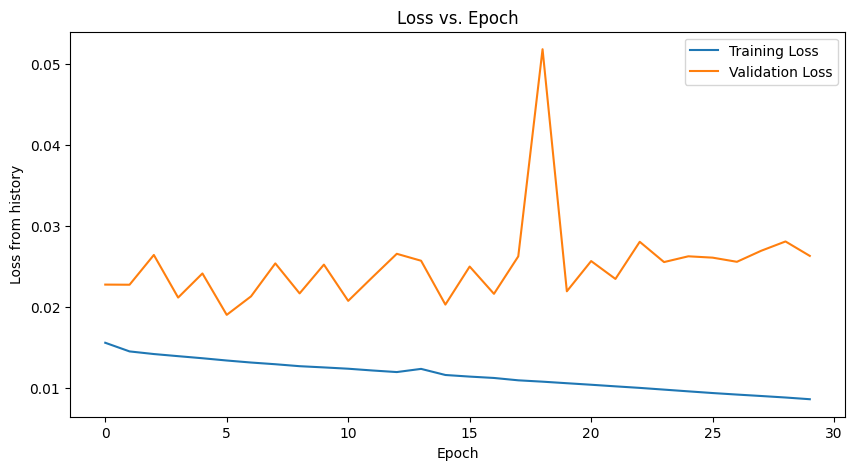

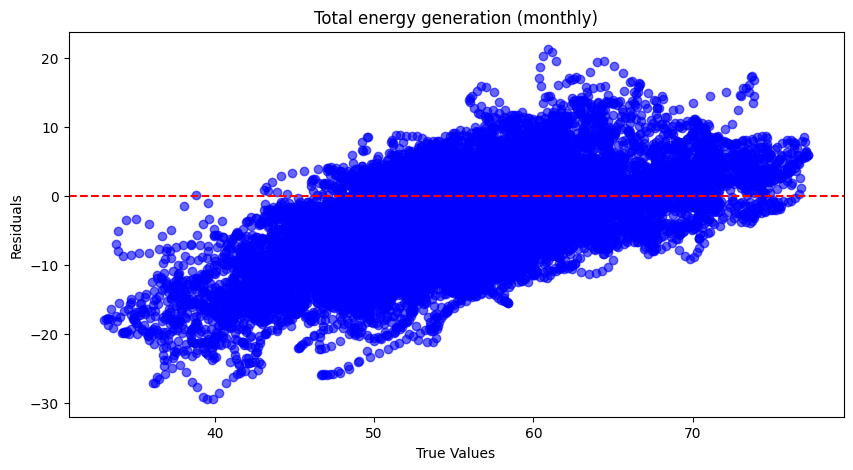

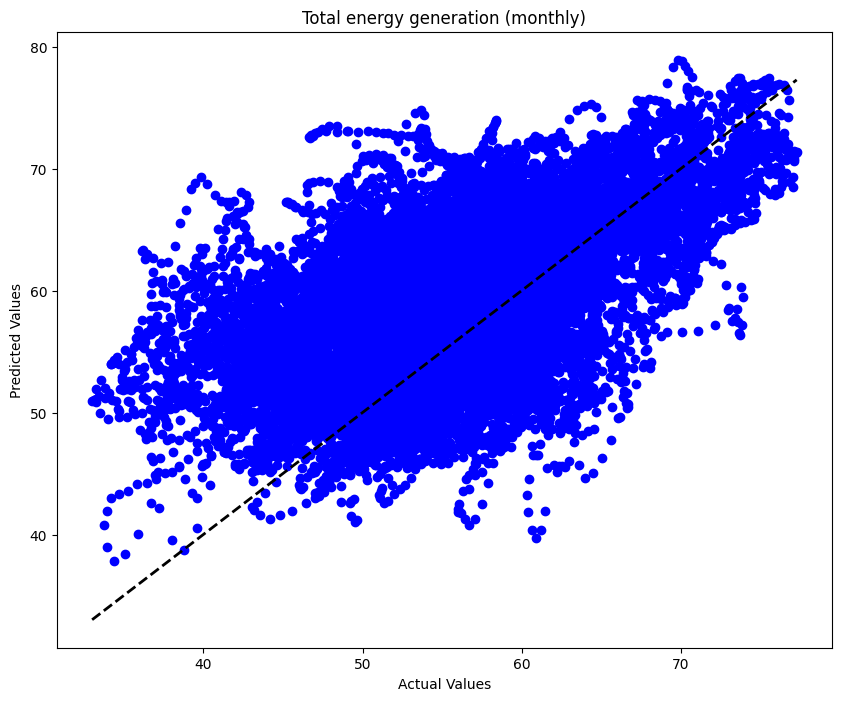

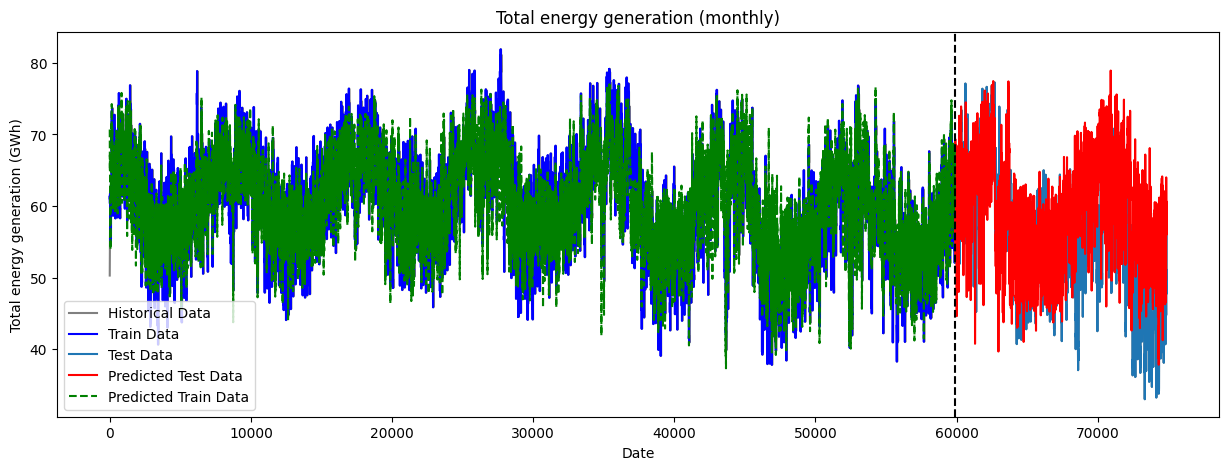

In [567]:
target = 'Total_energy_generation_gwh'
features = ['Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh']  # You can add other features if needed
result = lstm_mlvrt(target, data, features=features, lookback=30, sampling_frequency=None,
                    rolling_mean=30, detrend=False, moving_average=False, ma_window=None)

#### Fetuare importnce 

In [ ]:
#pip install shap

In [ ]:
import shap
def extract_feature_importance_lstm(model, X_train, X_test):
    # Create a SHAP explainer for the LSTM model
    explainer = shap.Explainer(model)

    # Compute SHAP values for the test data
    shap_values = explainer.shap_values(X_test)

    # Plot feature importance using summary_plot
    shap.summary_plot(shap_values, X_test, plot_type='bar')

    # Return SHAP values for further analysis if needed
    return shap_values

In [ ]:
def lstm_model_fancy(target, data_df, features, lookback=12, sampling_frequency='M', rolling_mean=None, detrend=False, moving_average=False, ma_window=None):
    #return model, X_train_lstm, X_test_lstm

In [ ]:

# Train the LSTM model and get the model object and data
model, X_train_lstm, X_test_lstm = lstm_model_fancy(target=, data_df=data_df, features, lookback=12, sampling_frequency='M', rolling_mean=None, detrend=False, moving_average=False, ma_window=None)
# Call the extract_feature_importance_lstm function
shap_values = extract_feature_importance_lstm(model, X_train_lstm, X_test_lstm)

In [378]:
features= ['Date', 'Solar_gwh', 'Total_other_renewable_gwh']#
#Other potential target 
#'Wind_onshore_gwh', Wind_offshore_gwh', 'Other_renewable_gwh', 'Total_other_renewable_gwh'

In [280]:
#target = 'Total_energy_generation_gwh'
#dfs = data_df[['Date', 'Solar_gwh', 'Total_other_renewable_gwh',target]]
#dfs.head()

In [281]:
columns_to_keep = ['Date', 'Solar_gwh', 'Total_other_renewable_gwh','Total_energy_generation_gwh']
dfs = data_df[columns_to_keep].copy()
dfs.head()


,Date,Solar_gwh,Total_other_renewable_gwh,Total_energy_generation_gwh
0,2015-01-01,0.0,9.66900,51.45925
1,2015-01-01,0.0,9.86225,49.98825
2,2015-01-01,0.0,10.00325,49.26525
3,2015-01-01,0.0,9.97275,48.53800
4,2015-01-01,0.0,10.03125,48.63000


In [113]:
dfs.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
74874    False
74875    False
74876    False
74877    False
74878    False
Length: 74879, dtype: bool

In [167]:
# Set the target column
target = 'Total_other_renewable_gwh'
#dfs = data_df[['Date', 'Solar_gwh', 'Total_other_renewable_gwh',target]]

# Extract features and the target variable from the DataFrame
features = ['Date', 'Solar_gwh', 'Total_other_renewable_gwh']
X = dfs[['Date'] + features]
y = dfs[['Date', target]]

# Drop any duplicate rows in the DataFrame
X.drop_duplicates(subset='Date', keep='first', inplace=True)
y.drop_duplicates(subset='Date', keep='first', inplace=True)

# Convert 'Date' column to datetime format
X['Date'] = pd.to_datetime(X['Date'])
y['Date'] = pd.to_datetime(y['Date'])

# Resample data at a monthly frequency and aggregate using mean
X = X.groupby('Date').mean()
y = y.groupby('Date').mean()

# Set 'Date' column as the index
X.set_index('Date', inplace=True)
y.set_index('Date', inplace=True)

lookback = 12  # Use a larger lookback window for monthly data

# Normalize data using Min-Max scaling
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))
data_scaled_X = scaler_X.fit_transform(X.values)
data_scaled_y = scaler_y.fit_transform(y.values.reshape(-1, 1))  # Reshape y to 2D array

# Prepare the input sequences for LSTM
def create_sequences(data, lookback):
    X_seq, y_seq = [], []
    for i in range(len(data) - lookback):
        X_seq.append(data[i:i+lookback, :-1])
        y_seq.append(data[i+lookback, -1])
    return np.array(X_seq), np.array(y_seq)

X_lstm, y_lstm = create_sequences(data_scaled_X, lookback)

# Split the data into train and test sets with an 80-20 split ratio
train_size = int(len(X_lstm) * 0.8)
X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size:]
y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size:]

# LSTM model
model = Sequential()
model.add(LSTM(units=64, activation='relu', input_shape=(lookback, len(features)-1), return_sequences=True))  # First LSTM layer
model.add(LSTM(units=32, activation='relu'))  # Second LSTM layer with 32 units
model.add(Dense(1))
model.compile(loss='mse', optimizer='adam')
history = model.fit(X_train_lstm, y_train_lstm, epochs=100, batch_size=30, validation_data=(X_test_lstm, y_test_lstm), verbose=1)

# Access training and validation loss from history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# LSTM prediction on test and train data
y_pred_train_lstm = model.predict(X_train_lstm)
y_pred_test_lstm = model.predict(X_test_lstm)

# Inverse transform the scaled data to get the original scale
y_pred_train_lstm = scaler_y.inverse_transform(y_pred_train_lstm).flatten()  # Flatten y_pred
y_pred_test_lstm = scaler_y.inverse_transform(y_pred_test_lstm).flatten()
y_train_lstm = scaler_y.inverse_transform(y_train_lstm).flatten()
y_test_lstm = scaler_y.inverse_transform(y_test_lstm).flatten()

# Compute metrics for LSTM
train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)

print("Train RMSE:", train_rmse)
print("Train MSE:", train_mse)
print("Train MAE:", train_mae)
print("Train R2 Score:", train_r2)

print("Test RMSE:", test_rmse)
print("Test MSE:", test_mse)
print("Test MAE:", test_mae)
print("Test R2 Score:", test_r2)

# Calculate residuals
residuals = y_test_lstm - y_pred_test_lstm

# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title(title_main)
plt.show()

# Plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test_lstm, y_pred_test_lstm, label=' ', color='blue')
plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)
#plt.legend()
plt.show()

# Plot actual and predicted test data for LSTM
plt.figure(figsize=(15, 5))
test_index = y.index[train_size:]
plt.plot(y.index, y[target], label='Historical Data', color='gray')
plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
plt.legend()
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xlabel('Date')
plt.show()

print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape)


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_74360/4044094326.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop_duplicates(subset='Date', keep='first', inplace=True)
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_74360/4044094326.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y.drop_duplicates(subset='Date', keep='first', inplace=True)


ValueError: cannot assemble with duplicate keys

### Rolling mean

In [ ]:
columns_to_keep = ['Date', 'Solar_gwh', 'Total_other_renewable_gwh','Total_energy_generation_gwh']
dfs = data_df[columns_to_keep].copy()

In [168]:
# Set the target column
target = 'Total_other_renewable_gwh'
#dfs = data_df[['Date', 'Solar_gwh', 'Total_other_renewable_gwh', target]]

# Extract features and the target variable from the DataFrame
features = ['Date', 'Solar_gwh', 'Total_other_renewable_gwh']
X = dfs[['Date'] + features]
y = dfs[['Date', target]]

# Drop any duplicate rows in the DataFrame
X.drop_duplicates(subset='Date', keep='first', inplace=True)
y.drop_duplicates(subset='Date', keep='first', inplace=True)

# Convert 'Date' column to datetime format
X['Date'] = pd.to_datetime(X['Date'])
y['Date'] = pd.to_datetime(y['Date'])

# Set 'Date' column as the index
X.set_index('Date', inplace=True)
y.set_index('Date', inplace=True)

lookback = 12  # Use a larger lookback window

# Resample data at a monthly frequency and aggregate using mean
X = X.resample('M').mean()
y = y.resample('M').mean()

# Normalize data using Min-Max scaling
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))
data_scaled_X = scaler_X.fit_transform(X.values)
data_scaled_y = scaler_y.fit_transform(y.values.reshape(-1, 1))  # Reshape y to 2D array

# Prepare the input sequences for LSTM
def create_sequences(data, lookback):
    X_seq, y_seq = [], []
    for i in range(len(data) - lookback):
        X_seq.append(data[i:i+lookback, :-1])
        y_seq.append(data[i+lookback, -1])
    return np.array(X_seq), np.array(y_seq)

X_lstm, y_lstm = create_sequences(data_scaled_X, lookback)

# Split the data into train and test sets with an 80-20 split ratio
train_size = int(len(X_lstm) * 0.8)
X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size:]
y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size:]

# LSTM model
model = Sequential()
model.add(LSTM(units=64, activation='relu', input_shape=(lookback, len(features)-1), return_sequences=True))  # First LSTM layer
model.add(LSTM(units=32, activation='relu'))  # Second LSTM layer with 32 units
model.add(Dense(1))
model.compile(loss='mse', optimizer='adam')
history = model.fit(X_train_lstm, y_train_lstm, epochs=100, batch_size=30, validation_data=(X_test_lstm, y_test_lstm), verbose=1)

# Access training and validation loss from history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# LSTM prediction on test and train data
y_pred_train_lstm = model.predict(X_train_lstm)
y_pred_test_lstm = model.predict(X_test_lstm)

# Inverse transform the scaled data to get the original scale
y_pred_train_lstm = scaler_y.inverse_transform(y_pred_train_lstm).flatten()  # Flatten y_pred
y_pred_test_lstm = scaler_y.inverse_transform(y_pred_test_lstm).flatten()
y_train_lstm = scaler_y.inverse_transform(y_train_lstm).flatten()
y_test_lstm = scaler_y.inverse_transform(y_test_lstm).flatten()

# Compute metrics for LSTM
train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)

print("Train RMSE:", train_rmse)
print("Train MSE:", train_mse)
print("Train MAE:", train_mae)
print("Train R2 Score:", train_r2)

print("Test RMSE:", test_rmse)
print("Test MSE:", test_mse)
print("Test MAE:", test_mae)
print("Test R2 Score:", test_r2)

# Calculate residuals
residuals = y_test_lstm - y_pred_test_lstm

# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title(title_main)
plt.show()

# Plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test_lstm, y_pred_test_lstm, label=' ', color='blue')
plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)
#plt.legend()
plt.show()

# Plot actual and predicted test data for LSTM
plt.figure(figsize=(15, 5))
test_index = y.index[train_size:]
plt.plot(y.index, y[target], label='Historical Data', color='gray')
plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
plt.legend()
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xlabel('Date')
plt.show()

print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape)


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_74360/1595234529.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop_duplicates(subset='Date', keep='first', inplace=True)
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_74360/1595234529.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y.drop_duplicates(subset='Date', keep='first', inplace=True)


ValueError: cannot assemble with duplicate keys

## Fitting of raw data

In [ ]:
data_df.columns

In [381]:
columns_to_keep = ['Date', 'Solar_gwh', 'Total_other_renewable_gwh','Total_energy_generation_gwh']
dfs = data_df[columns_to_keep].copy()
dfs.head()

#data_df.head()

,Date,Solar_gwh,Total_other_renewable_gwh,Total_energy_generation_gwh
0,2015-01-01,0.0,9.66900,51.45925
1,2015-01-01,0.0,9.86225,49.98825
2,2015-01-01,0.0,10.00325,49.26525
3,2015-01-01,0.0,9.97275,48.53800
4,2015-01-01,0.0,10.03125,48.63000


In [382]:

# Load the data and preprocess it
# Assuming your data is stored in 'data_df' DataFrame
# data_df = pd.read_csv('your_data.csv')

# Convert 'Date' column to datetime format
dfs['Date'] = pd.to_datetime(dfs['Date'])
# Set 'Date' column as the index
dfs.set_index('Date', inplace=True)

# Define input and target variables
features = ['Solar_gwh', 'Total_other_renewable_gwh']
target = 'Total_other_renewable_gwh'
dfs = dfs[features + [target]]

# Split the data into training and testing sets
train_size = int(0.8 * len(dfs))
train_data, test_data = dfs[:train_size], dfs[train_size:]

# Normalize the data
scaler = MinMaxScaler()
train_data = scaler.fit_transform(train_data)
test_data = scaler.transform(test_data)

# Prepare the data for LSTM
def prepare_lstm_data(data, time_steps=1):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps)])
        y.append(data[i + time_steps, -1])  # Taking only the last target variable (Total_other_renewable_gwh)
    return np.array(X), np.array(y)

time_steps = 1


X_train_lstm, y_train_lstm = prepare_lstm_data(train_data, time_steps)
X_test_lstm, y_test_lstm = prepare_lstm_data(test_data, time_steps)

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
model.add(Dense(units=1))  # Single output for one target variable
model.compile(optimizer='adam', loss='mse')

# Train the LSTM model
history = model.fit(X_train_lstm, y_train_lstm, validation_data=(X_test_lstm, y_test_lstm), epochs=50, batch_size=64, verbose=1)

# Make predictions using the trained model
y_pred_train_lstm = model.predict(X_train_lstm)
y_pred_test_lstm = model.predict(X_test_lstm)

# Rescale the predictions to the original scale
y_train_lstm = scaler.inverse_transform(y_train_lstm.reshape(-1, 1)).flatten()
y_test_lstm = scaler.inverse_transform(y_test_lstm.reshape(-1, 1)).flatten()
y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm).flatten()
y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm).flatten()

# Calculate evaluation metrics for LSTM
mse_train_lstm = mean_squared_error(y_train_lstm, y_pred_train_lstm)
mae_train_lstm = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
mse_test_lstm = mean_squared_error(y_test_lstm, y_pred_test_lstm)
mae_test_lstm = mean_absolute_error(y_test_lstm, y_pred_test_lstm)

print("LSTM Model Evaluation:")
print(f"Train MSE: {mse_train_lstm:.4f}")
print(f"Train MAE: {mae_train_lstm:.4f}")
print(f"Test MSE: {mse_test_lstm:.4f}")
print(f"Test MAE: {mae_test_lstm:.4f}")

# Plot the variables
plt.figure(figsize=(12, 6))
plt.plot(dfs.index[:train_size], dfs[target][:train_size], label='Training Target', color='blue')
plt.plot(dfs.index[train_size:], dfs[target][train_size:], label='Testing Target', color='green')
plt.plot(dfs.index[time_steps:train_size], y_pred_train_lstm, label='Training Predictions', color='orange')
plt.plot(dfs.index[train_size+time_steps:], y_pred_test_lstm, label='Testing Predictions', color='red')
plt.xlabel('Date')
plt.ylabel('Total Other Renewable (GWh)')
plt.title('LSTM Model - Solar Energy Production Prediction')
plt.legend()
plt.grid(True)
plt.show()

# Plot validation and loss function vs epoch
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Training and Validation Loss vs. Epoch')
plt.legend()
plt.grid(True)
plt.show()


Epoch 1/50
936/936 [==============================] - 3s 1ms/step - loss: 0.0084 - val_loss: 6.4401e-04
Epoch 2/50
936/936 [==============================] - 1s 1ms/step - loss: 4.1158e-04 - val_loss: 6.1639e-04
Epoch 3/50
936/936 [==============================] - 1s 1ms/step - loss: 4.0767e-04 - val_loss: 6.2541e-04
Epoch 4/50
936/936 [==============================] - 1s 1ms/step - loss: 4.0666e-04 - val_loss: 6.1165e-04
Epoch 5/50
936/936 [==============================] - 1s 1ms/step - loss: 4.0753e-04 - val_loss: 6.1261e-04
Epoch 6/50
936/936 [==============================] - 1s 1ms/step - loss: 4.0749e-04 - val_loss: 6.2868e-04
Epoch 7/50
936/936 [==============================] - 1s 1ms/step - loss: 4.0640e-04 - val_loss: 6.3534e-04
Epoch 8/50
936/936 [==============================] - 1s 1ms/step - loss: 4.0431e-04 - val_loss: 6.0377e-04
Epoch 9/50
936/936 [==============================] - 1s 1ms/step - loss: 4.0111e-04 - val_loss: 6.1640e-04
Epoch 10/50
936/936 [===========

ValueError: non-broadcastable output operand with shape (59902,1) doesn't match the broadcast shape (59902,3)

In [ ]:

# Calculate residuals
residuals = y_test_lstm - y_pred_test_lstm

# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title(title_main)
plt.show()

# Plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test_lstm, y_pred_test_lstm, label=' ', color='blue')
plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)
#plt.legend()
plt.show()

# Plot actual and predicted test data for LSTM
plt.figure(figsize=(15, 5))
test_index = y.index[train_size:]
plt.plot(y.index, y[target], label='Historical Data', color='gray')
plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
plt.legend()
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xlabel('Date')
plt.show()

print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape)


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_53121/577601713.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/30
5990/5990 [==============================] - 25s 4ms/step - loss: 0.6550 - val_loss: 0.1745
Epoch 2/30
5990/5990 [==============================] - 26s 4ms/step - loss: 0.1694 - val_loss: 0.1383
Epoch 3/30
5990/5990 [==============================] - 26s 4ms/step - loss: 0.1483 - val_loss: 0.1364
Epoch 4/30
5990/5990 [==============================] - 26s 4ms/step - loss: 0.1377 - val_loss: 0.1483
Epoch 5/30
5990/5990 [==============================] - 25s 4ms/step - loss: 0.1311 - val_loss: 0.1209
Epoch 6/30
5990/5990 [==============================] - 26s 4ms/step - loss: 0.1269 - val_loss: 0.1330
Epoch 7/30
5990/5990 [==============================] - 26s 4ms/step - loss: 0.1236 - val_loss: 0.1218
Epoch 8/30
5990/5990 [==============================] - 26s 4ms/step - loss: 0.1212 - val_loss: 0.1168
Epoch 9/30
5990/5990 [==============================] - 27s 4ms/step - loss: 0.1199 - val_loss: 0.1149
Epoch 10/30
5990/5990 [==============================] - 27s 5ms/step - l

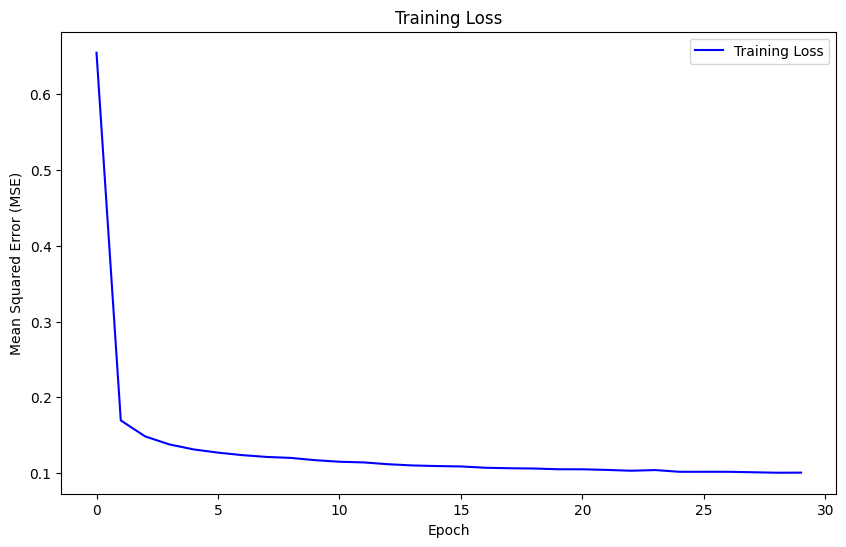

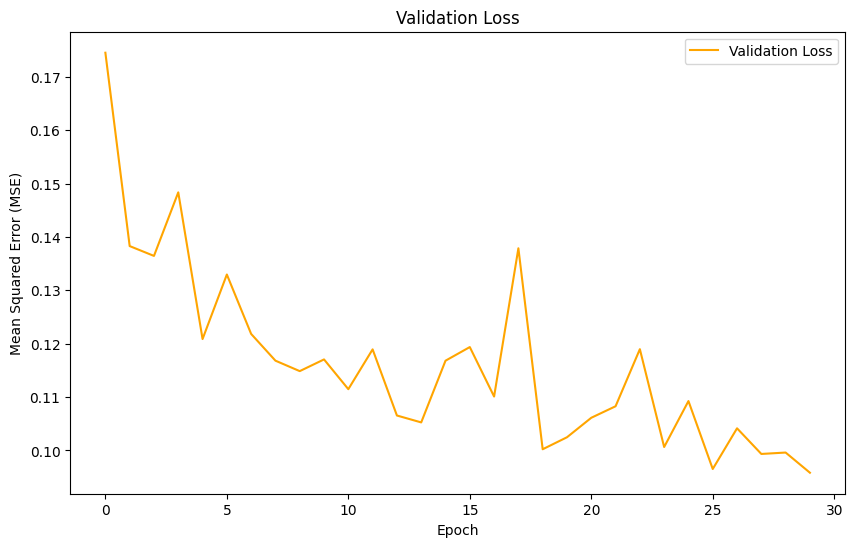

468/468 [==============================] - 1s 2ms/step
LSTM Model Metrics on train data:
Mean Squared Error (MSE): 0.09381822443810173
Root Mean Squared Error (RMSE): 0.30629760762712743
Mean Absolute Error (MAE): 0.17177145986323195
R-squared (R2): 0.9984191176938052

LSTM Model Metrics on test data:
Mean Squared Error (MSE): 0.09582513187440843
Root Mean Squared Error (RMSE): 0.3095563468488547
Mean Absolute Error (MAE): 0.17360098727333723
R-squared (R2): 0.9983377382558657


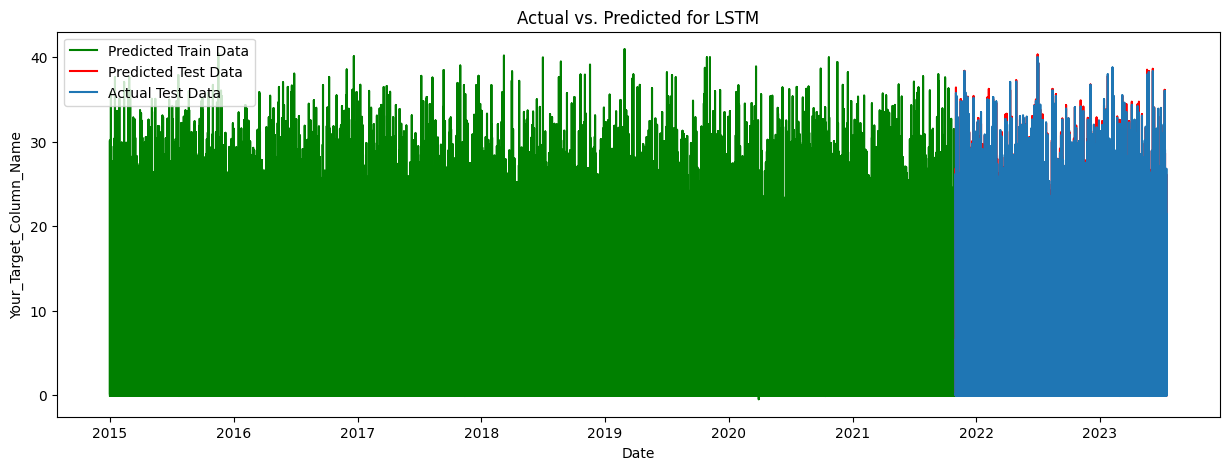

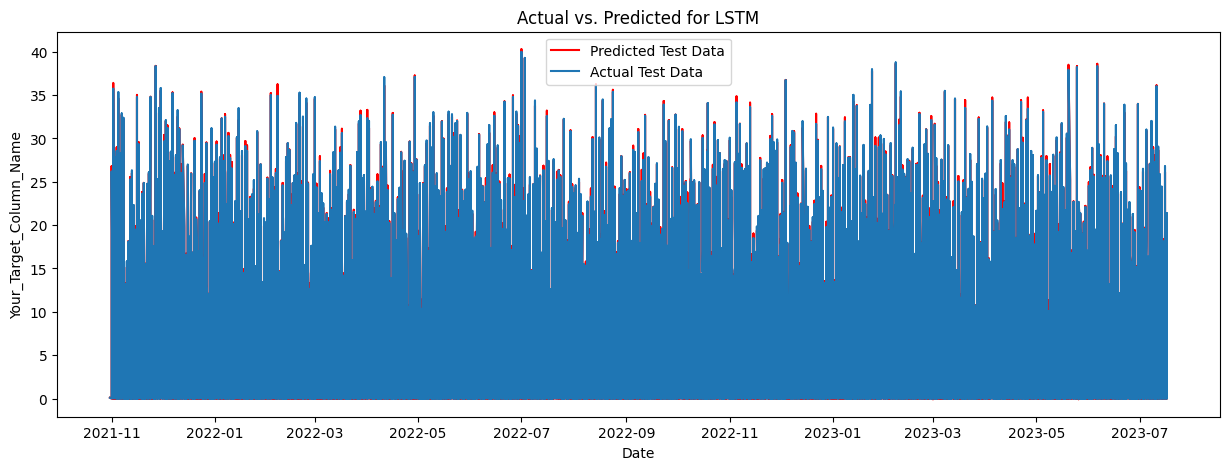

In [282]:
# Select the necessary columns 'Date' and the target column 'target'
dfs = data_df[['Date', target]]

# Convert 'Date' column to datetime format and set it as the index
dfs['Date'] = pd.to_datetime(dfs['Date'])
dfs.set_index('Date', inplace=True)

lookback = 7  # This variable represents the number of time steps to look back for creating the input sequence for the LSTM model.
X_lstm, y_lstm = [], []

for i in range(len(dfs) - lookback):
    X_lstm.append(dfs[target].iloc[i:i + lookback].values)
    y_lstm.append(dfs[target].iloc[i + lookback])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

# Train-test split for LSTM
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_lstm, y_lstm, test_size=0.2, random_state=42)

# LSTM model
model = Sequential()
model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1)))  # Input shape is (lookback, 1) for univariate
model.add(Dense(1))
model.compile(loss='mse', optimizer='adam')
history = model.fit(X_train_lstm, y_train_lstm, epochs=30, batch_size=10, validation_data=(X_test_lstm, y_test_lstm), verbose=1)



# Access training and validation loss from history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Separate plots for training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.title('Training Loss')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.title('Validation Loss')
plt.show()

# LSTM prediction on test and train data
y_pred_train_lstm = model.predict(X_train_lstm)
y_pred_test_lstm = model.predict(X_test_lstm)

# Calculate evaluation metrics for both test and train data
mse_train_lstm = mean_squared_error(y_train_lstm, y_pred_train_lstm)
mae_train_lstm = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
rmse_train_lstm = mean_squared_error(y_train_lstm, y_pred_train_lstm, squared=False)
r2_train_lstm = r2_score(y_train_lstm, y_pred_train_lstm)

mse_test_lstm = mean_squared_error(y_test_lstm, y_pred_test_lstm)
mae_test_lstm = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
rmse_test_lstm = mean_squared_error(y_test_lstm, y_pred_test_lstm, squared=False)
r2_test_lstm = r2_score(y_test_lstm, y_pred_test_lstm)

# Print the metrics for both test and train data
print("LSTM Model Metrics on train data:")
print("Mean Squared Error (MSE):", mse_train_lstm)
print("Root Mean Squared Error (RMSE):", rmse_train_lstm)
print("Mean Absolute Error (MAE):", mae_train_lstm)
print("R-squared (R2):", r2_train_lstm)

print("\nLSTM Model Metrics on test data:")
print("Mean Squared Error (MSE):", mse_test_lstm)
print("Root Mean Squared Error (RMSE):", rmse_test_lstm)
print("Mean Absolute Error (MAE):", mae_test_lstm)
print("R-squared (R2):", r2_test_lstm)

# Plot actual, train data, and predicted test data for LSTM
plt.figure(figsize=(15, 5))
plt.plot(dfs.index[:len(y_pred_train_lstm)], y_pred_train_lstm, label='Predicted Train Data', color='green')
plt.plot(dfs.index[-len(y_test_lstm):], y_pred_test_lstm, label='Predicted Test Data', color='red')
plt.plot(dfs.index[-len(y_test_lstm):], y_test_lstm, label='Actual Test Data', color='#1f76b4')
plt.legend()
plt.title('Actual vs. Predicted for LSTM')
plt.ylabel('Your_Target_Column_Name')
plt.xlabel('Date')
plt.show()


# Plot actual, train data, and predicted test data for LSTM
plt.figure(figsize=(15, 5))
plt.plot(dfs.index[-len(y_test_lstm):], y_pred_test_lstm, label='Predicted Test Data', color='red')
plt.plot(dfs.index[-len(y_test_lstm):], y_test_lstm, label='Actual Test Data', color='#1f76b4')
plt.legend()
plt.title('Actual vs. Predicted for LSTM')
plt.ylabel('Your_Target_Column_Name')
plt.xlabel('Date')
plt.show()


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_53121/3853990949.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/50
2992/2992 [==============================] - 82s 27ms/step - loss: nan - val_loss: nan
Epoch 2/50
2992/2992 [==============================] - 87s 29ms/step - loss: nan - val_loss: nan
Epoch 3/50
2992/2992 [==============================] - 85s 29ms/step - loss: nan - val_loss: nan
Epoch 4/50
2992/2992 [==============================] - 85s 28ms/step - loss: nan - val_loss: nan
Epoch 5/50
2992/2992 [==============================] - 86s 29ms/step - loss: nan - val_loss: nan
Epoch 6/50
2992/2992 [==============================] - 86s 29ms/step - loss: nan - val_loss: nan
Epoch 7/50
2992/2992 [==============================] - 82s 27ms/step - loss: nan - val_loss: nan
Epoch 8/50
2992/2992 [==============================] - 80s 27ms/step - loss: nan - val_loss: nan
Epoch 9/50
2992/2992 [==============================] - 122s 41ms/step - loss: nan - val_loss: nan
Epoch 10/50
2992/2992 [==============================] - 81s 27ms/step - loss: nan - val_loss: nan
Epoch 11/50
2992/2

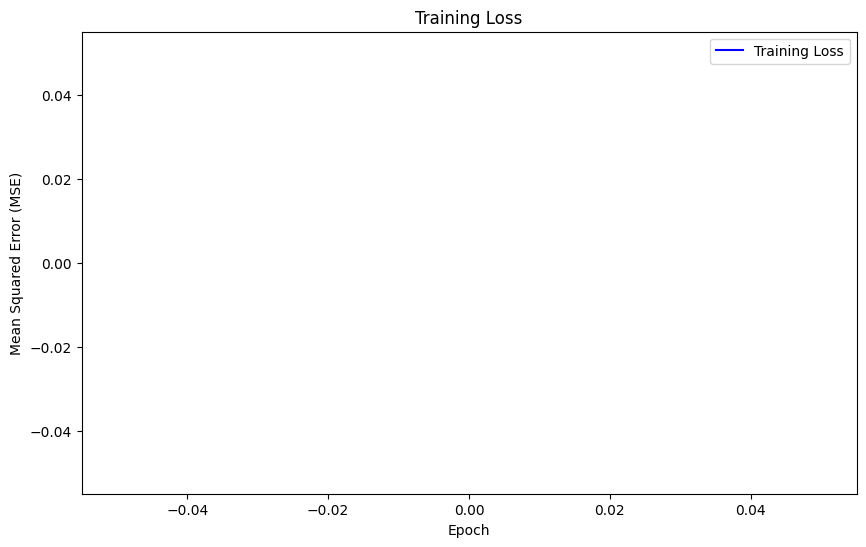

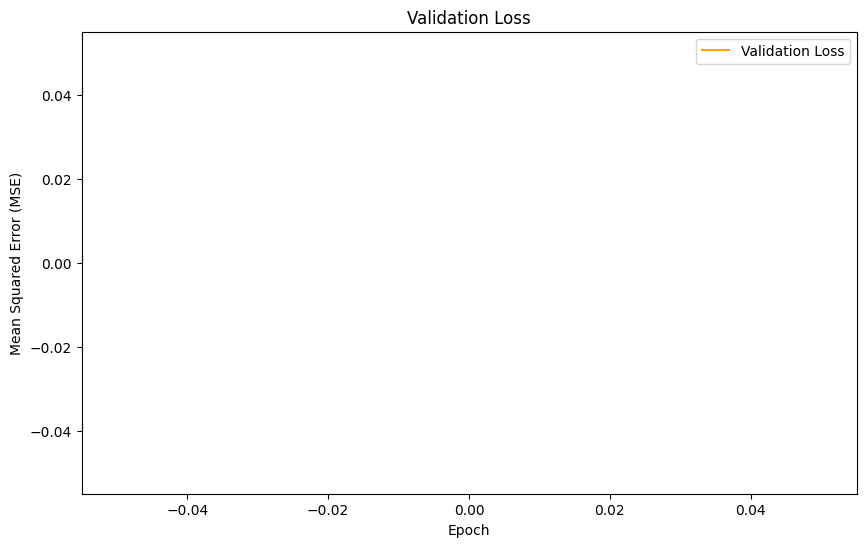

468/468 [==============================] - 5s 11ms/step


ValueError: Input contains NaN.

In [283]:
# Select the necessary columns 'Date' and the target column 'target'
dfs = data_df[['Date', target]]

# Convert 'Date' column to datetime format and set it as the index
dfs['Date'] = pd.to_datetime(dfs['Date'])
dfs.set_index('Date', inplace=True)

lookback = 100  # This variable represents the number of time steps to look back for creating the input sequence for the LSTM model.
X_lstm, y_lstm = [], []

for i in range(len(dfs) - lookback):
    X_lstm.append(dfs[target].iloc[i:i + lookback].values)
    y_lstm.append(dfs[target].iloc[i + lookback])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

# Train-test split for LSTM
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_lstm, y_lstm, test_size=0.2, random_state=42)

# LSTM model
model = Sequential()
model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1)))  # Input shape is (lookback, 1) for univariate
model.add(Dense(1))
model.compile(loss='mse', optimizer='adam')
history = model.fit(X_train_lstm, y_train_lstm, epochs=50, batch_size=20, validation_data=(X_test_lstm, y_test_lstm), verbose=1)



# Access training and validation loss from history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Separate plots for training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.title('Training Loss')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.title('Validation Loss')
plt.show()

# LSTM prediction on test and train data
y_pred_train_lstm = model.predict(X_train_lstm)
y_pred_test_lstm = model.predict(X_test_lstm)

# Calculate evaluation metrics for both test and train data
mse_train_lstm = mean_squared_error(y_train_lstm, y_pred_train_lstm)
mae_train_lstm = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
rmse_train_lstm = mean_squared_error(y_train_lstm, y_pred_train_lstm, squared=False)
r2_train_lstm = r2_score(y_train_lstm, y_pred_train_lstm)

mse_test_lstm = mean_squared_error(y_test_lstm, y_pred_test_lstm)
mae_test_lstm = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
rmse_test_lstm = mean_squared_error(y_test_lstm, y_pred_test_lstm, squared=False)
r2_test_lstm = r2_score(y_test_lstm, y_pred_test_lstm)

# Print the metrics for both test and train data
print("LSTM Model Metrics on train data:")
print("Mean Squared Error (MSE):", mse_train_lstm)
print("Root Mean Squared Error (RMSE):", rmse_train_lstm)
print("Mean Absolute Error (MAE):", mae_train_lstm)
print("R-squared (R2):", r2_train_lstm)

print("\nLSTM Model Metrics on test data:")
print("Mean Squared Error (MSE):", mse_test_lstm)
print("Root Mean Squared Error (RMSE):", rmse_test_lstm)
print("Mean Absolute Error (MAE):", mae_test_lstm)
print("R-squared (R2):", r2_test_lstm)

# Plot actual, train data, and predicted test data for LSTM
plt.figure(figsize=(15, 5))
plt.plot(dfs.index[:len(y_pred_train_lstm)], y_pred_train_lstm, label='Predicted Train Data', color='green')
plt.plot(dfs.index[-len(y_test_lstm):], y_pred_test_lstm, label='Predicted Test Data', color='red')
plt.plot(dfs.index[-len(y_test_lstm):], y_test_lstm, label='Actual Test Data', color='#1f76b4')
plt.legend()
plt.title('Actual vs. Predicted for LSTM')
plt.ylabel('Your_Target_Column_Name')
plt.xlabel('Date')
plt.show()


# Plot actual, train data, and predicted test data for LSTM
plt.figure(figsize=(15, 5))
plt.plot(dfs.index[-len(y_test_lstm):], y_pred_test_lstm, label='Predicted Test Data', color='red')
plt.plot(dfs.index[-len(y_test_lstm):], y_test_lstm, label='Actual Test Data', color='#1f76b4')
plt.legend()
plt.title('Actual vs. Predicted for LSTM')
plt.ylabel('Your_Target_Column_Name')
plt.xlabel('Date')
plt.show()


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_53121/279911210.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/5
29949/29949 [==============================] - 82s 3ms/step - loss: 0.6762 - val_loss: 0.1349
Epoch 2/5
29949/29949 [==============================] - 84s 3ms/step - loss: 0.1632 - val_loss: 0.1215
Epoch 3/5
29949/29949 [==============================] - 77s 3ms/step - loss: 0.1453 - val_loss: 0.1308
Epoch 4/5
29949/29949 [==============================] - 77s 3ms/step - loss: 0.1358 - val_loss: 0.1189
Epoch 5/5
29949/29949 [==============================] - 73s 2ms/step - loss: 0.1312 - val_loss: 0.1132


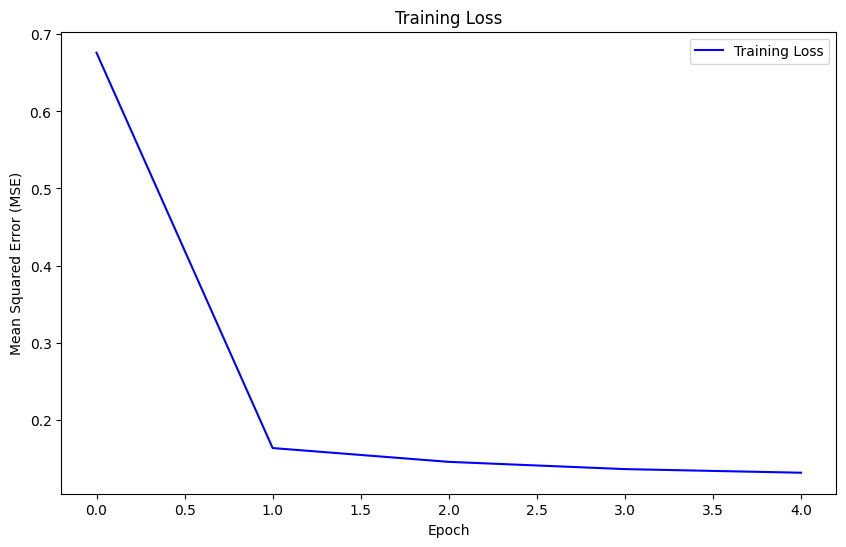

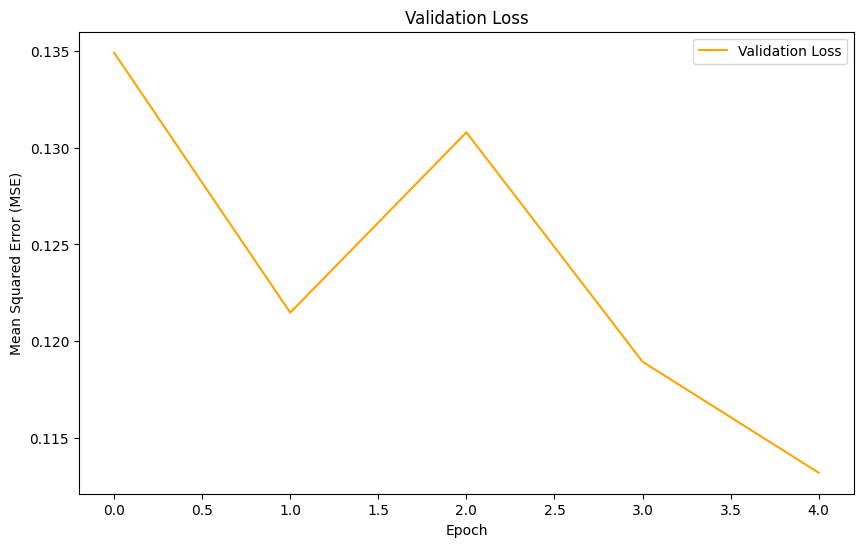

468/468 [==============================] - 0s 877us/step
LSTM Model Metrics on train data:
Mean Squared Error (MSE): 0.11187355973022695
Root Mean Squared Error (RMSE): 0.334475050983219
Mean Absolute Error (MAE): 0.18305803147978295
R-squared (R2): 0.9981148765906859

LSTM Model Metrics on test data:
Mean Squared Error (MSE): 0.11319783717469932
Root Mean Squared Error (RMSE): 0.3364488626443836
Mean Absolute Error (MAE): 0.18426874581110897
R-squared (R2): 0.9980363769861453


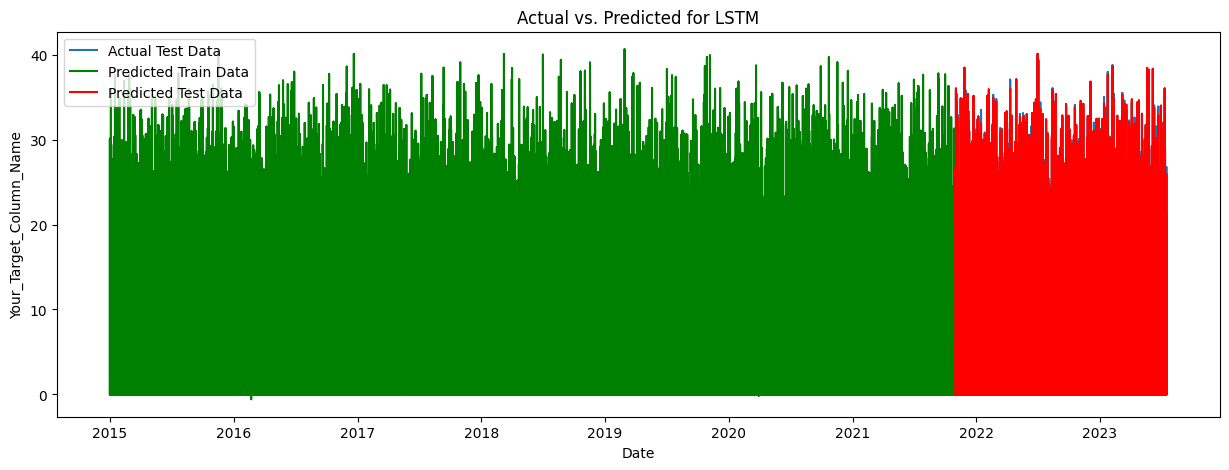

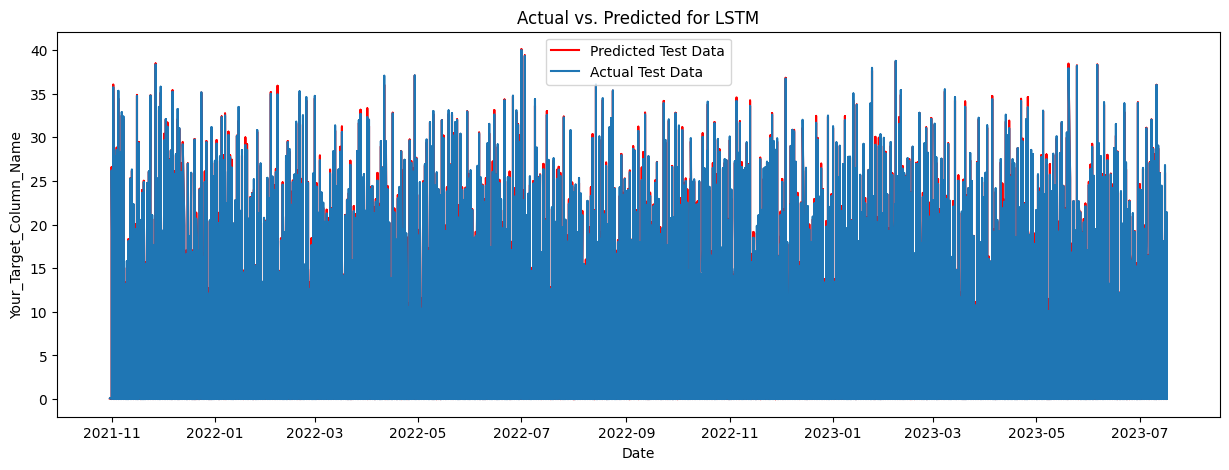

In [ ]:
# Select the necessary columns 'Date' and the target column 'target'
dfs = data_df[['Date', target]]

# Convert 'Date' column to datetime format and set it as the index
dfs['Date'] = pd.to_datetime(dfs['Date'])
dfs.set_index('Date', inplace=True)

lookback = 365  # This variable represents the number of time steps to look back for creating the input sequence for the LSTM model.
X_lstm, y_lstm = [], []

for i in range(len(dfs) - lookback):
    X_lstm.append(dfs[target].iloc[i:i + lookback].values)
    y_lstm.append(dfs[target].iloc[i + lookback])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

# Train-test split for LSTM
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_lstm, y_lstm, test_size=0.2, random_state=42)

# LSTM model
model = Sequential()
model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))  # First LSTM layer
model.add(LSTM(units=32, activation='relu'))  # Second LSTM layer with 32 units
model.add(Dense(1))
model.compile(loss='mse', optimizer='adam')
history = model.fit(X_train_lstm, y_train_lstm, epochs=30, batch_size=10, validation_data=(X_test_lstm, y_test_lstm), verbose=1)

# Access training and validation loss from history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Separate plots for training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.title('Training Loss')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.title('Validation Loss')
plt.show()

# LSTM prediction on test and train data
y_pred_train_lstm = model.predict(X_train_lstm)
y_pred_test_lstm = model.predict(X_test_lstm)

# Calculate evaluation metrics for both test and train data
mse_train_lstm = mean_squared_error(y_train_lstm, y_pred_train_lstm)
mae_train_lstm = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
rmse_train_lstm = mean_squared_error(y_train_lstm, y_pred_train_lstm, squared=False)
r2_train_lstm = r2_score(y_train_lstm, y_pred_train_lstm)

mse_test_lstm = mean_squared_error(y_test_lstm, y_pred_test_lstm)
mae_test_lstm = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
rmse_test_lstm = mean_squared_error(y_test_lstm, y_pred_test_lstm, squared=False)
r2_test_lstm = r2_score(y_test_lstm, y_pred_test_lstm)

# Print the metrics for both test and train data
print("LSTM Model Metrics on train data:")
print("Mean Squared Error (MSE):", mse_train_lstm)
print("Root Mean Squared Error (RMSE):", rmse_train_lstm)
print("Mean Absolute Error (MAE):", mae_train_lstm)
print("R-squared (R2):", r2_train_lstm)

print("\nLSTM Model Metrics on test data:")
print("Mean Squared Error (MSE):", mse_test_lstm)
print("Root Mean Squared Error (RMSE):", rmse_test_lstm)
print("Mean Absolute Error (MAE):", mae_test_lstm)
print("R-squared (R2):", r2_test_lstm)


# Plot actual, train data, and predicted test data for LSTM
plt.figure(figsize=(15, 5))
plt.plot(dfs.index[:len(y_pred_train_lstm)], y_pred_train_lstm, label='Predicted Train Data', color='green')
plt.plot(dfs.index[-len(y_test_lstm):], y_pred_test_lstm, label='Predicted Test Data', color='red')
plt.plot(dfs.index[-len(y_test_lstm):], y_test_lstm, label='Actual Test Data', color='#1f76b4')
plt.legend()
plt.title('Actual vs. Predicted for LSTM')
plt.ylabel('Your_Target_Column_Name')
plt.xlabel('Date')
plt.show()


# Plot actual, train data, and predicted test data for LSTM
plt.figure(figsize=(15, 5))
plt.plot(dfs.index[-len(y_test_lstm):], y_pred_test_lstm, label='Predicted Test Data', color='red')
plt.plot(dfs.index[-len(y_test_lstm):], y_test_lstm, label='Actual Test Data', color='#1f76b4')
plt.legend()
plt.title('Actual vs. Predicted for LSTM')
plt.ylabel('Your_Target_Column_Name')
plt.xlabel('Date')
plt.show()

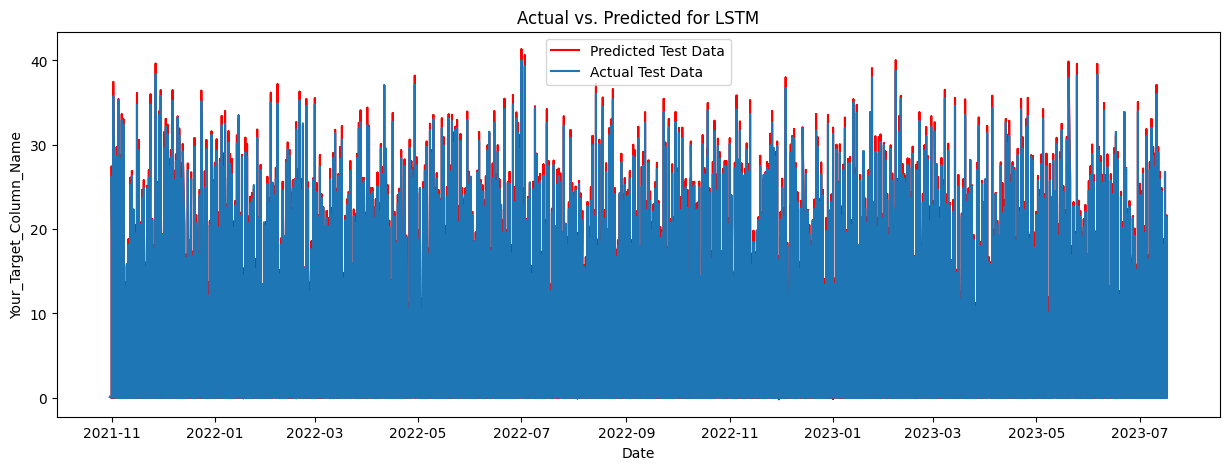

In [ ]:
# Plot actual, train data, and predicted test data for LSTM
plt.figure(figsize=(15, 5))
plt.plot(dfs.index[-len(y_test_lstm):], y_pred_test_lstm, label='Predicted Test Data', color='red')
plt.plot(dfs.index[-len(y_test_lstm):], y_test_lstm, label='Actual Test Data', color='#1f76b4')
plt.legend()
plt.title('Actual vs. Predicted for LSTM')
plt.ylabel('Your_Target_Column_Name')
plt.xlabel('Date')
plt.show()

#### Parameter explanations:
- Let's break down the code and explain each part:

- dfs = data_df[['Date', target]]: This line selects the 'Date' column and the target column from the data_df DataFrame and creates a new DataFrame called dfs containing these two columns.
- dfs['Date'] = pd.to_datetime(dfs['Date']): This line converts the 'Date' column in the dfs DataFrame to datetime format using the pd.to_datetime() function.
- dfs.set_index('Date', inplace=True): This line sets the 'Date' column as the index of the dfs DataFrame.
- lookback = 7: This variable represents the number of time steps to look back for creating the input sequence for the LSTM model.
- X_lstm, y_lstm = [], []: These empty lists will be used to store the input sequences and corresponding target values for the LSTM model.
- The following loop generates input sequences and target values for the LSTM model:
- X_lstm.append(dfs[target].iloc[i:i + lookback].values): It appends a sequence of 'lookback' values from the target column to the X_lstm list as input sequences for the model.
- y_lstm.append(dfs[target].iloc[i + lookback]): It appends the value immediately following the input sequence to the y_lstm list as the target value for the corresponding input sequence.
- X_lstm = np.array(X_lstm): This converts the list of input sequences X_lstm into a NumPy array.
- y_lstm = np.array(y_lstm): This converts the list of target values y_lstm into a NumPy array.
- X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_lstm, y_lstm, test_size=0.2, random_state=42): This line performs a train-test split on the input sequences and target values. It splits the data into training and testing sets, where 20% of the data is used for testing and 80% for training. The random_state=42 ensures reproducibility.
- The following lines build the LSTM model:
- model = Sequential(): This initializes a sequential model.
- model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1))): This adds an LSTM layer with 64 units, ReLU activation, and an input shape of (lookback, 1). The 1 indicates that the data is univariate.
- model.add(Dense(1)): This adds a dense output layer with one unit.
- model.compile(loss='mse', optimizer='adam'): This compiles the model using mean squared error as the loss function and the Adam optimizer.
- history = model.fit(...): This line trains the LSTM model on the training data and validates it using the validation data (X_test_lstm and y_test_lstm). The training loss and validation loss are stored in the history object.
- The next two code blocks plot the training and validation loss over the epochs.
- The code then predicts the target values for both the training and test data using the trained LSTM model and stores them in y_pred_train_lstm and y_pred_test_lstm, respectively.
- The following code calculates and prints the evaluation metrics for the LSTM model on the test data:
- mse_test_lstm: Mean Squared Error
- rmse_test_lstm: Root Mean Squared Error
- mae_test_lstm: Mean Absolute Error
- r2_test_lstm: R-squared (coefficient of determination)
- Note: The performance metrics for the test data look very good, but it's essential to ensure that the model is not overfitting and that the results are meaningful and realistic for your specific dataset. Further analysis and evaluation may be necessary to validate the model's performance.

In [ ]:
dfs = data_df[['Date',  target]]

#### LSTM with sampling of monthly data resolution 

Epoch 1/5


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_53121/1874827430.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


36/36 [==============================] - 1s 10ms/step - loss: 0.1042 - val_loss: 0.1112
Epoch 2/5
36/36 [==============================] - 0s 3ms/step - loss: 0.0526 - val_loss: 0.0957
Epoch 3/5
36/36 [==============================] - 0s 3ms/step - loss: 0.0369 - val_loss: 0.0705
Epoch 4/5
36/36 [==============================] - 0s 3ms/step - loss: 0.0259 - val_loss: 0.0304
Epoch 5/5
1/1 [==============================] - 0s 12ms/step


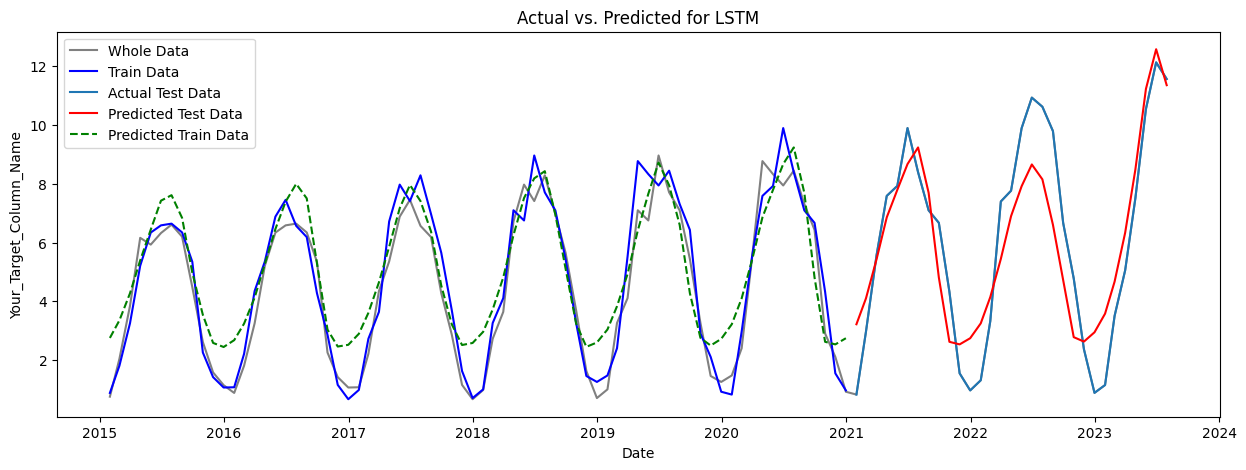

In [203]:
#target = 'Solar_gwh'
#target1 = 'Total_energy_generation_gwh'

# Select the necessary columns 'Date' and the target column 'target'
dfs = data_df[['Date', target]]

# Convert 'Date' column to datetime format and set it as the index
dfs['Date'] = pd.to_datetime(dfs['Date'])
dfs.set_index('Date', inplace=True)

# Resample data at a monthly frequency and aggregate using mean (you can choose other aggregation methods if needed)
dfs_monthly = dfs.resample('M').mean()

lookback = 12  # Use a larger lookback window for monthly data

# Normalize data using Min-Max scaling
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(dfs_monthly)

# Prepare the input sequences for LSTM
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

X_lstm, y_lstm = create_sequences(data_scaled, lookback)

# Split the data into train and test sets with a 80-20 split ratio
train_size = int(len(X_lstm) * 0.8)
X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size-lookback:]
y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size-lookback:]

# LSTM model
model = Sequential()
model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))  # First LSTM layer
model.add(LSTM(units=32, activation='relu'))  # Second LSTM layer with 32 units
model.add(Dense(1))
model.compile(loss='mse', optimizer='adam')
history = model.fit(X_train_lstm, y_train_lstm, epochs=5, batch_size=2, validation_data=(X_test_lstm, y_test_lstm), verbose=1)

# Access training and validation loss from history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Rest of the code remains the same...

# LSTM prediction on test and train data
y_pred_train_lstm = model.predict(X_train_lstm)
y_pred_test_lstm = model.predict(X_test_lstm)

# Inverse transform the scaled data to get the original scale
y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm)
y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm)
y_train_lstm = scaler.inverse_transform(y_train_lstm)
y_test_lstm = scaler.inverse_transform(y_test_lstm)

# Rest of the code remains the same...

# Plot actual, train data, and predicted test data for LSTM
plt.figure(figsize=(15, 5))
train_index = dfs_monthly.index[:train_size][-len(y_train_lstm):]  # Use this line to get the correct time index
test_index = dfs_monthly.index[train_size:]
plt.plot(dfs_monthly.index, dfs_monthly[target], label='Whole Data', color='gray')
plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
plt.plot(test_index, y_test_lstm, label='Actual Test Data', color='#1f76b4')
plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
plt.legend()
plt.title('Actual vs. Predicted for LSTM')
plt.ylabel('Your_Target_Column_Name')
plt.xlabel('Date')
plt.show()


In [519]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback, :-1])
        y.append(data[i+lookback, -1])
    return np.array(X), np.array(y)

def detrend_data(data, window):
    detrended = data.rolling(window=window, min_periods=1, center=True).mean()
    detrended = detrended.fillna(method='bfill')
    return detrended

def lstm_mlvrt(target, data_df, features, lookback=12, sampling_frequency='M', rolling_mean=None, detrend=False, moving_average=False, ma_window=None):
    # Prepare the input data
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    if sampling_frequency:
        data_df['Date'] = pd.to_datetime(data_df['Date'])
        data_df.set_index('Date', inplace=True)
        dfs_resampled = data_df[features + [target]].resample(sampling_frequency).mean()
    else:
        dfs_resampled = data_df[features + [target]]
    
    if rolling_mean:
        for feature in features + [target]:
            dfs_resampled[feature] = dfs_resampled[feature].rolling(window=rolling_mean, min_periods=1, center=True).mean()
            dfs_resampled[feature] = dfs_resampled[feature].fillna(method='bfill')
    
    if detrend:
        result = seasonal_decompose(dfs_resampled[target], model='additive', period=12)
        dfs_resampled[target] = dfs_resampled[target] - result.trend
        dfs_resampled[target] = dfs_resampled[target].fillna(method='bfill')
    
    if moving_average:
        for feature in features + [target]:
            dfs_resampled[feature] = dfs_resampled[feature].rolling(window=ma_window, min_periods=1, center=True).mean()
            dfs_resampled[feature] = dfs_resampled[feature].fillna(method='bfill')
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs_resampled.values)
    
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.8)
    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size:]
    
    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, len(features)), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_train_lstm, y_train_lstm, epochs=30, batch_size=5, validation_data=(X_test_lstm, y_test_lstm), verbose=1)
    
    # LSTM prediction on test and train data
    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    # Inverse transform the scaled data to get the original scale
    y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm).flatten()
    y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm).flatten()
    y_train_lstm = scaler.inverse_transform(y_train_lstm.reshape(-1, 1)).flatten()
    y_test_lstm = scaler.inverse_transform(y_test_lstm.reshape(-1, 1)).flatten()
    
    # Compute metrics for LSTM
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
    train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
    test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
    train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
    test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
    train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
    test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)
    
    # Calculate residuals
    residuals = y_test_lstm - y_pred_test_lstm
    
    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    # Plot loss versus epoch and validation loss versus epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()
    
    # Create a residual plot
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()
    
    # Plot actual vs. predicted values
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm, y_pred_test_lstm, label='', color='blue')
    plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()
    
    # Plot actual, train data, and predicted test data for LSTM
    plt.figure(figsize=(15, 5))
    train_index = dfs_resampled.index[:train_size][-len(y_train_lstm):]
    test_index = dfs_resampled.index[train_size:]
    plt.plot(dfs_resampled.index, dfs_resampled[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.legend()
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()
    


    #print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape)

    return {
        'train_rmse': train_rmse,
        'train_mse': train_mse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'residuals': residuals,
        'y_test_predicted': y_pred_test_lstm,
        'model': model,
        'X_train_lstm': X_train_lstm,
        'X_test_lstm': X_test_lstm,
    }

In [520]:
data = data_df.copy()

In [518]:
target = 'Total_energy_generation_gwh'
features = ['Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh']  # You can add other features if needed
result = lstm_mlvrt(target, data, features=features, lookback=12, sampling_frequency= 'M',
                    rolling_mean=None, detrend=False, moving_average=False, ma_window=None)

Epoch 1/30
15/15 [==============================] - 2s 19ms/step - loss: 0.3080 - val_loss: 0.0661
Epoch 2/30
15/15 [==============================] - 0s 6ms/step - loss: 0.1042 - val_loss: 0.1970
Epoch 3/30
15/15 [==============================] - 0s 5ms/step - loss: 0.0682 - val_loss: 0.1280
Epoch 4/30
15/15 [==============================] - 0s 5ms/step - loss: 0.0610 - val_loss: 0.1415
Epoch 5/30
15/15 [==============================] - 0s 5ms/step - loss: 0.0569 - val_loss: 0.1451
Epoch 6/30
15/15 [==============================] - 0s 5ms/step - loss: 0.0405 - val_loss: 0.1621
Epoch 7/30
15/15 [==============================] - 0s 6ms/step - loss: 0.0339 - val_loss: 0.1057
Epoch 8/30
15/15 [==============================] - 0s 6ms/step - loss: 0.0287 - val_loss: 0.0656
Epoch 9/30
15/15 [==============================] - 0s 6ms/step - loss: 0.0322 - val_loss: 0.0709
Epoch 10/30
15/15 [==============================] - 0s 6ms/step - loss: 0.0315 - val_loss: 0.1360
Epoch 11/30
15/15 

ValueError: non-broadcastable output operand with shape (72,1) doesn't match the broadcast shape (72,4)